# 01 - Análisis Exploratorio de Datos

## 1. Comprensión del Problema

La pérdida de clientes (**customer churn**) representa uno de los principales desafíos para las empresas, ya que la adquisición de nuevos clientes suele requerir mayores recursos que la retención de clientes existentes.

En este proyecto se busca desarrollar una solución basada en Machine Learning capaz de identificar clientes con alta probabilidad de abandonar un servicio de telecomunicaciones, permitiendo anticipar posibles bajas y apoyar la definición de estrategias de retención.

El análisis se complementará con una etapa de segmentación de clientes mediante aprendizaje no supervisado, con el objetivo de identificar grupos de clientes con características y comportamientos similares.

### 1.1 Objetivos del proyecto

Los principales objetivos son:

- Analizar las características de los clientes y su relación con el abandono del servicio.
- Desarrollar un modelo de clasificación binaria para predecir la probabilidad de churn.
- Identificar los factores más relevantes asociados a la pérdida de clientes mediante técnicas de interpretabilidad.
- Crear segmentos de clientes utilizando técnicas de clustering para descubrir diferentes perfiles dentro de la base de clientes.
- Desplegar una aplicación interactiva que permita realizar predicciones y explorar los segmentos identificados.

### 1.2 Definición del problema de Machine Learning

Este proyecto se plantea como un problema de clasificación binaria supervisada.

La variable objetivo será:

**Churn**

- `Yes`: el cliente abandonó el servicio.
- `No`: el cliente continúa utilizando el servicio.

El modelo aprenderá patrones a partir de las características históricas de los clientes para estimar la probabilidad de abandono de nuevos clientes. Adicionalmente, se desarrollará un análisis de segmentación no supervisada utilizando las características de los clientes, sin considerar la variable objetivo, con el propósito de identificar grupos con comportamientos similares.

### 1.3 Pregunta de negocio

> ¿Es posible identificar anticipadamente a los clientes con mayor riesgo de abandono y comprender los perfiles de clientes existentes para diseñar mejores estrategias de retención?

## 2. Descripción del Dataset

El dataset utilizado en este proyecto corresponde a información histórica de clientes de una empresa de telecomunicaciones, con el objetivo de analizar los factores asociados al abandono del servicio.

Cada registro representa un cliente y contiene información relacionada con sus características demográficas, servicios contratados, tipo de contrato, información de facturación y comportamiento dentro de la relación comercial.

### 2.1 Información general

- **Número de registros:** 7,043 clientes.
- **Número de variables:** 21 columnas.
- **Variable objetivo:** `Churn`.
- **Tipo de problema principal:** Clasificación binaria.
- **Problema complementario:** Segmentación de clientes mediante clustering.

### 2.2 Descripción de las variables

El dataset contiene variables agrupadas en las siguientes categorías:

#### Información demográfica

Características generales del cliente:

- Género (`gender`).
- Edad del cliente (``SeniorCitizen	``).
- Estado de pareja (`Partner`).
- Dependientes (`Dependents`).

#### Información de cuenta

Variables relacionadas con la antigüedad y relación comercial:

- Antigüedad del cliente (`tenure`).
- Tipo de contrato (`Contract`).
- Facturación electrónica (`PaperlessBilling`).
- Método de pago (`PaymentMethod`).

#### Servicios contratados

Información sobre los servicios utilizados por cada cliente:

- Servicio telefónico (`PhoneService`).
- Múltiples líneas (`MultipleLines`).
- Servicio de internet (`InternetService`).
- Seguridad en línea (`OnlineSecurity`).
- Respaldo en línea (`OnlineBackup`).
- Protección del dispositivo (`DeviceProtection`).
- Soporte técnico (`TechSupport`).
- Servicios de streaming (`StreamingTV`, `StreamingMovies`).

#### Información financiera

Variables relacionadas con los pagos del cliente:

- Cargos mensuales (`MonthlyCharges`).
- Cargos totales acumulados (`TotalCharges`).

#### Variable objetivo

La variable objetivo del proyecto es:

**`Churn`**

Representa si el cliente abandonó el servicio:

- `Yes`: el cliente canceló el servicio.
- `No`: el cliente continúa siendo cliente.

### 2.3 Fuente del Dataset

El dataset corresponde al conjunto **Telco Customer Churn**, ampliamente utilizado para análisis de retención de clientes y desarrollo de modelos predictivos de clasificación.

## 3. Inspección Inicial

En esta sección se realiza una revisión inicial del dataset con el objetivo de comprender su tamaño, estructura y tipos de variables.

### 3.1 Importación de librerías y carga del dataset

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

# Add project root to path
sys.path.append(os.path.abspath(".."))

# Load the autoreload extension to automatically reload modules when they change
# Set autoreload mode to 2: reload all modules before executing user code
%load_ext autoreload
%autoreload 2 

# import eda modules
from src.eda.visualizations import (
    plot_categorical_distributions,
    plot_categorical_churn_rates,
    plot_numerical_distributions,
    plot_continuous_by_categorical,
    plot_churn_rate_by_group
)

from src.eda.statistical_test import(
    chi_square_analysis,
    mann_whitney_analysis
)

# Load dataset
df = pd.read_csv("../data/raw/Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 3.2 Inspección inicial de los datos

In [3]:
# Dataset dimensions
print(f'Dataset dimensions: \nRows: {df.shape[0]}, Columns: {df.shape[1]}')

Dataset dimensions: 
Rows: 7043, Columns: 21


In [4]:
# General structure and data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:
# Count duplicated rows
print(f"Total duplicated rows: {df.duplicated().sum()}")

Total duplicated rows: 0


In [6]:
# Count missing values per column
print("========= Missing values in each column =========")
with pd.option_context('display.max_rows', None):
    print(df.isnull().sum().sort_values(ascending=False))

========= Missing values in each column =========
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


A continuación se realizará un Análisis Exploratorio de Datos (EDA), cuyo objetivo será comprender las características principales de los clientes y analizar la relación entre las variables disponibles y el abandono del servicio (**Churn**).

Durante las siguientes etapas se explorará la variable objetivo y los diferentes grupos de variables del dataset, identificando patrones, diferencias entre los clientes que abandonaron y aquellos que permanecieron activos, así como posibles factores asociados con una mayor probabilidad de cancelación.

Además del análisis descriptivo y visual, se utilizarán pruebas estadísticas y medidas de asociación cuando sean apropiadas para complementar los hallazgos observados y evaluar si determinadas relaciones presentan evidencia estadística.

El análisis se enfocará principalmente en responder preguntas como:

- ¿Cuál es la proporción de clientes que abandonan el servicio?
- ¿Qué características presentan mayor relación con el churn?
- ¿Cómo se relacionan el tipo de contrato, los servicios contratados y la antigüedad del cliente con el abandono?
- ¿Existe alguna relación entre los cargos del cliente y la probabilidad de abandono?

Los hallazgos obtenidos durante esta etapa servirán como base para identificar variables candidatas para el modelo y orientar la creación de características derivadas (*feature engineering*) en las siguientes fases del proyecto.

## 4. Análisis de la Variable Objetivo (`Churn`)

La variable objetivo del proyecto es `Churn`, que indica si un cliente abandonó el servicio de la compañía. Antes de analizar la relación entre las características de los clientes y el abandono, es necesario comprender la distribución de esta variable y determinar si existe un desbalance entre sus categorías.

Este análisis permitirá establecer una referencia inicial sobre la proporción de clientes que abandonan el servicio y aquellos que permanecen, además de identificar posibles consideraciones que deberán tenerse en cuenta durante la etapa de modelado.

El análisis de esta sección se centrará en:

- Examinar la distribución de las categorías de `Churn`.
- Calcular la cantidad y proporción de clientes que abandonaron y permanecieron.
- Evaluar el nivel de desbalance de la variable objetivo.
- Identificar las implicaciones de esta distribución para la selección de métricas de evaluación del modelo.

Una vez comprendida la distribución de la variable objetivo, se analizará cómo las diferentes características de los clientes se relacionan con el abandono del servicio.

### 4.1 Distribución de la variable objetivo

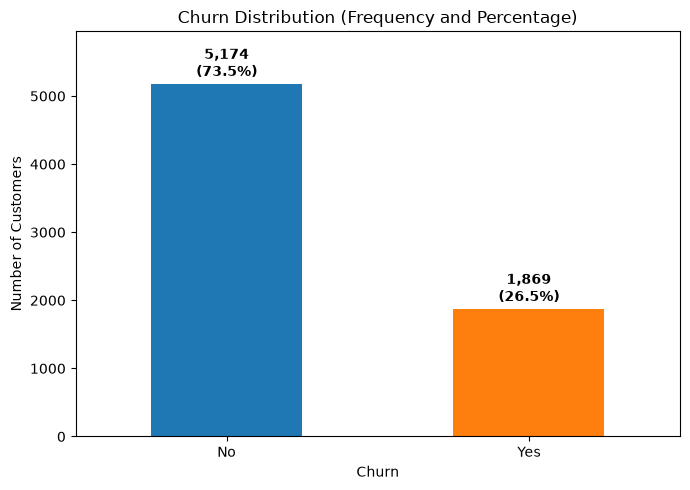

In [7]:
# Calculate counts and percentages ensuring matching indices
churn_counts = df["Churn"].value_counts()
churn_percentages = df["Churn"].value_counts(normalize=True).mul(100)

# Initialize a single plot figure
fig, ax = plt.subplots(figsize=(7, 5))

# Plot absolute frequencies
churn_counts.plot(kind="bar", ax=ax, color=["#1f77b4", "#ff7f0e"])
ax.set_title("Churn Distribution (Frequency and Percentage)")
ax.set_xlabel("Churn")
ax.set_ylabel("Number of Customers")
ax.tick_params(axis="x", rotation=0)

# Annotate bars with both absolute count and percentage values
for i, label in enumerate(churn_counts.index):
    count = churn_counts[label]
    pct = churn_percentages[label]
    
    ax.text(
        i, 
        count + (churn_counts.max() * 0.01), 
        f"{count:,}\n({pct:.1f}%)", 
        ha="center", 
        va="bottom", 
        fontsize=10, 
        fontweight="bold"
    )

# Adjust y-axis limit to prevent label clipping
ax.set_ylim(0, churn_counts.max() * 1.15)

plt.tight_layout()
plt.show()


De los 7,043 clientes presentes en el dataset, 5,174 (73.5%) permanecen con la compañía (`No`), mientras que 1,869 (26.5%) han abandonado el servicio (`Yes`).

Por lo tanto, aproximadamente 1 de cada 4 clientes corresponde a un caso de churn.

La distribución muestra un desbalance moderado entre las clases. Aunque la categoría `No` representa la mayoría de los registros, la clase `Yes` cuenta con un número considerable de observaciones para desarrollar un modelo de clasificación.

### 4.2 Implicaciones para el Modelado

El desbalance observado debe ser considerado durante la evaluación de los modelos. En este escenario, un modelo podría alcanzar un nivel elevado de `Accuracy` simplemente al predecir mayoritariamente la clase `No`, sin necesariamente tener una buena capacidad para identificar a los clientes que abandonan.

Por esta razón, durante la etapa de modelado no se utilizará `Accuracy` como única métrica de evaluación. Se prestará especial atención a métricas como *Precision, Recall, F1-Score y ROC-AUC*, considerando especialmente el desempeño sobre la clase minoritaria `Yes`.

La distribución de la variable objetivo proporciona así un punto de partida para comprender el problema de clasificación. Sin embargo, conocer únicamente cuántos clientes abandonan no permite explicar qué características están asociadas con el churn.

Por ello, en las siguientes secciones se analizarán los diferentes grupos de variables disponibles en el dataset, comparando el comportamiento de los clientes que permanecieron con aquellos que abandonaron el servicio. El objetivo será identificar patrones y relaciones que puedan aportar información relevante para las etapas posteriores de feature engineering y modelado.

## 5. Análisis de Variables Demográficas

En esta sección se analizará la relación entre las características demográficas de los clientes y el abandono del servicio (`Churn`).

El objetivo es determinar si existen diferencias en las tasas de abandono entre distintos perfiles demográficos y si estas variables podrían aportar información relevante para la predicción del churn.

Las variables que se analizarán son:

- `gender`: género del cliente.
- `SeniorCitizen`: indica si el cliente pertenece al grupo de adultos mayores.
- `Partner`: indica si el cliente tiene pareja.
- `Dependents`: indica si el cliente tiene dependientes.

Para las variables categóricas se analizará principalmente la **tasa de churn de cada categoría**, ya que esta métrica permite comparar directamente la proporción de clientes que abandonaron el servicio dentro de cada grupo. Además de observar las diferencias en las tasas de abandono, se considerará el tamaño de cada grupo para evitar interpretar diferencias basadas en categorías con un número reducido de observaciones.

Posteriormente, las diferencias observadas se complementarán mediante la **prueba Chi-cuadrado de independencia**, con el objetivo de evaluar si existe evidencia estadística de una asociación entre cada variable demográfica y `Churn`. Asimismo, se utilizará **Cramér's V** para estimar la magnitud de dichas asociaciones.

Los resultados de este análisis permitirán identificar posibles patrones de asociación entre las características demográficas y el churn, así como determinar qué variables podrían aportar información relevante para nuestro problema de clasificación.

### 5.1 Distribucion de variables demográficas

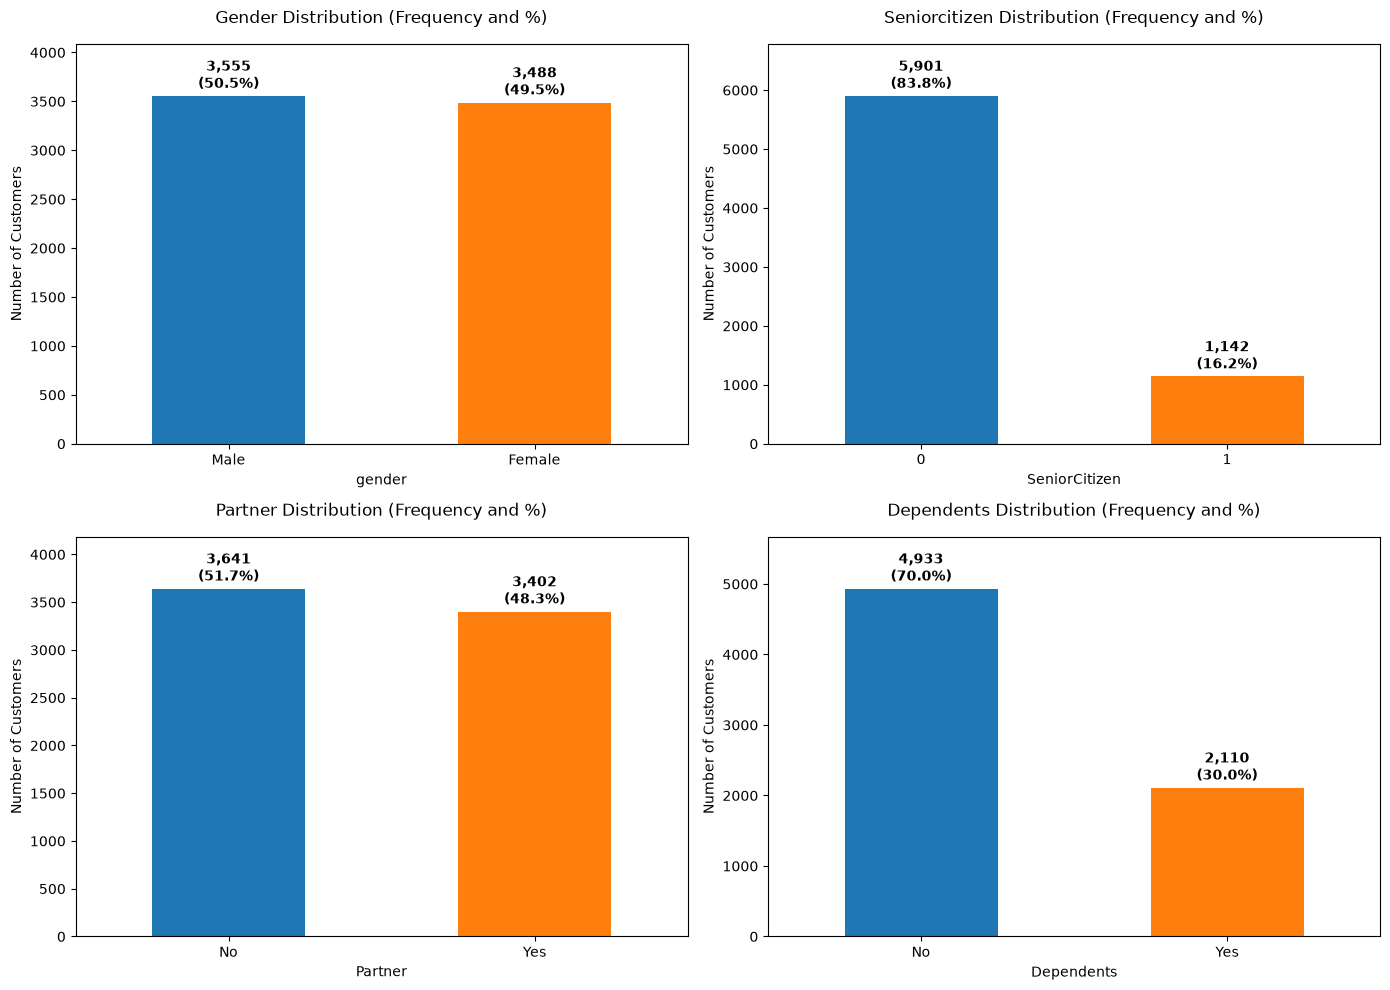

In [8]:
# Define the list of customer demographic features to analyze
demographic_features = ["gender", "SeniorCitizen", "Partner", "Dependents"]

# Plot distributions for the demographic features
plot_categorical_distributions(df, demographic_features)

La distribución de las variables demográficas muestra diferentes niveles de representación entre sus categorías.

En el caso de `gender`, la distribución es prácticamente equilibrada, con 3,555 clientes (50.48%) identificados como hombres y 3,488 (49.52%) como mujeres. La diferencia de menos de un punto porcentual indica que no existe un desbalance relevante entre ambas categorías.

La variable `SeniorCitizen` presenta una distribución más desigual. 5,901 clientes (83.79%) no pertenecen al grupo de adultos mayores, mientras que 1,142 (16.21%) sí pertenecen a este grupo. Esta diferencia deberá considerarse al analizar posteriormente las tasas de churn, especialmente al comparar grupos con tamaños diferentes.

En `Partner`, la distribución es relativamente equilibrada: 3,641 clientes (51.70%) no tienen pareja y 3,402 (48.30%) sí tienen pareja. Por lo tanto, ambas categorías cuentan con una cantidad suficiente de observaciones para realizar comparaciones posteriores.

Finalmente, `Dependents` presenta una distribución más desigual. 4,933 clientes (70.04%) no tienen dependientes, mientras que 2,110 (29.96%) sí los tienen. Al igual que en `SeniorCitizen`, el tamaño de los grupos deberá considerarse al interpretar las diferencias en las tasas de abandono.

En general, las variables presentan tamaños de grupo suficientes para analizar su relación con `Churn`. Sin embargo, la distribución de las categorías por sí sola no permite determinar si existe una asociación con el abandono. Por ello, el siguiente análisis comparará la tasa de churn dentro de cada categoría para identificar posibles diferencias en el comportamiento de abandono.

### 5.2 Tasa de abandono en variables demográficas

La tasa de abandono (Churn Rate) representa el porcentaje de clientes que abandonaron el servicio dentro de un grupo específico.

Se calcula como:

$$
\text{Churn Rate} =
\frac{\text{Número de clientes que abandonaron el servicio}}
{\text{Número total de clientes del grupo}}
\times 100
$$

<br>
Por ejemplo, si el 30% de los clientes de género *Male* abandonaron el servicio, significa que 3 de cada 10 clientes pertenecientes a ese grupo presentan `Churn = Yes`.

Esta métrica permite comparar el comportamiento de distintos grupos independientemente de su tamaño. Una tasa de abandono más alta indica una mayor proporción de clientes que abandonaron el servicio dentro de esa categoría, mientras que una tasa más baja indica una menor proporción de abandono.

Durante el análisis exploratorio, el Churn Rate se utilizará para:

- Identificar grupos con mayor proporción de abandono: permite detectar categorías en las que el churn se presenta con mayor frecuencia relativa.
- Comparar diferentes perfiles de clientes: facilita identificar diferencias en el comportamiento de abandono entre las categorías de una variable.
- Generar hipótesis para el análisis posterior: las diferencias observadas servirán como punto de partida para investigar si existe una asociación estadísticamente significativa entre las variables y `Churn`.

Es importante señalar que una diferencia en la tasa de abandono no implica necesariamente una relación causal. Por ello, cuando corresponda, las diferencias observadas se complementarán posteriormente con pruebas estadísticas y medidas de asociación.

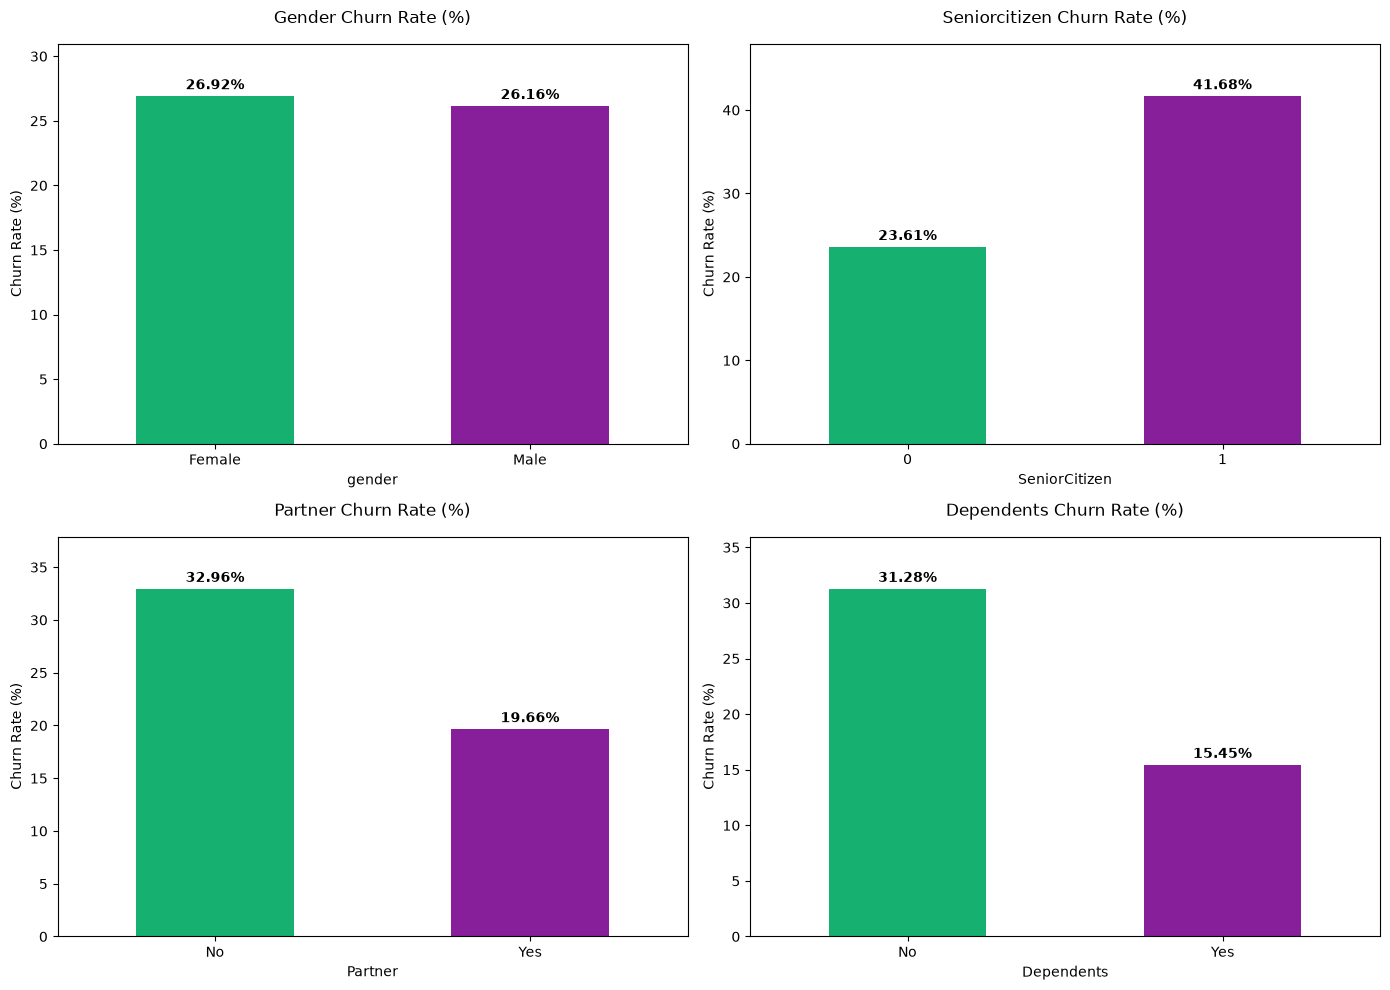

In [9]:
# Create a boolean target column where 'Yes' becomes True and 'No' becomes False
df["Churn_bool"] = df["Churn"].astype(str).str.lower() == "yes"

# Plot churn rates for the demographic features
plot_categorical_churn_rates(df, demographic_features, 'Churn_bool')

El análisis de la tasa de churn muestra diferencias importantes entre algunas de las categorías demográficas, aunque la magnitud de estas diferencias varía considerablemente entre variables.

En `gender`, las tasas de abandono son muy similares: 26.9% para mujeres y 26.2% para hombres. La diferencia de apenas 0.7 puntos porcentuales sugiere que, a nivel exploratorio, no existe una diferencia relevante en el comportamiento de abandono entre ambos grupos.

En `SeniorCitizen` se observa una diferencia considerable. Los clientes que no pertenecen al grupo de adultos mayores presentan una tasa de churn de 23.6%, mientras que aquellos que sí pertenecen a este grupo alcanzan un 41.7%. Esto representa una diferencia de 18.1 puntos porcentuales, lo que sugiere una posible asociación entre pertenecer al grupo de adultos mayores y una mayor tasa de abandono.

Para `Partner`, los clientes que no tienen pareja presentan una tasa de churn de 33.0%, frente a 19.7% entre aquellos que sí tienen pareja. La diferencia de 13.3 puntos porcentuales indica un patrón relevante que deberá considerarse en las siguientes etapas del análisis.

Finalmente, `Dependents` presenta una de las diferencias más marcadas. Los clientes sin dependientes tienen una tasa de churn de 31.3%, mientras que aquellos con dependientes presentan una tasa de 15.5%, una diferencia de 15.8 puntos porcentuales.

En conjunto, `gender` muestra una diferencia mínima en la tasa de abandono, mientras que `SeniorCitizen`, `Partner` y `Dependents` presentan diferencias considerablemente mayores. Estos resultados identifican patrones potencialmente relevantes para la predicción de churn, aunque no implican una relación causal. Su utilidad predictiva deberá evaluarse posteriormente junto con el resto de las variables disponibles y mediante técnicas de modelado.

### 5.3 Análisis estadístico de variables demográficas

El análisis de las distribuciones y las tasas de churn permitió identificar diferencias entre las categorías de cada variable demográfica. Sin embargo, estas diferencias descriptivas no permiten determinar por sí solas si existe evidencia estadística de una asociación con el abandono del servicio.

Para complementar el análisis exploratorio, se aplicará la prueba Chi-cuadrado de independencia a cada una de las variables demográficas. Esta prueba permitirá evaluar si existe una asociación estadísticamente significativa entre cada característica y la variable objetivo `Churn`.

Para cada variable demográfica se plantearán las siguientes hipótesis:

$$
H_0: \text{La variable demográfica y Churn son independientes.}
$$

$$
H_1: \text{La variable demográfica y Churn no son independientes.}
$$

Por ejemplo, para la variable `Partner`, la prueba busca responder la siguiente pregunta:

> ¿La categoría de `Partner` está asociada estadísticamente con el hecho de que un cliente abandone o no el servicio?

Un p-value inferior al nivel de significancia establecido ($\alpha = 0.05$) proporcionará evidencia suficiente para rechazar la hipótesis nula y considerar que existe una asociación estadísticamente significativa entre la variable analizada y `Churn`.

Sin embargo, el p-value no indica qué tan fuerte es dicha asociación. Por esta razón, se utilizará Cramér's V como medida del tamaño o fuerza de la asociación. Mientras que el p-value permite determinar si existe evidencia estadística de una asociación, Cramér's V permite evaluar la magnitud de dicha asociación, independientemente del tamaño de la muestra. Esto permitirá distinguir entre asociaciones estadísticamente significativas pero de baja magnitud y aquellas que presentan una relación más fuerte.

Para facilitar su interpretación, se utilizarán como referencia los puntos de corte propuestos por Jacob Cohen, adaptados como una guía heurística para este análisis:

| Cramér's V | Interpretación |
|---:|---|
| $V < 0.10$ | Muy baja |
| $0.10 \leq V < 0.30$ | Baja |
| $0.30 \leq V < 0.50$ | Moderada |
| $V \geq 0.50$ | Fuerte |

<br>

> **Nota metodológica:** Los puntos de corte utilizados para interpretar el valor de Cramér's V se emplearán únicamente como una referencia heurística para facilitar la interpretación de la magnitud de las asociaciones. Estos umbrales no constituyen criterios universales y deben interpretarse considerando el contexto del problema, las dimensiones de la tabla de contingencia y la magnitud práctica de la asociación.

Los resultados se utilizarán para identificar qué variables demográficas presentan evidencia de asociación con el churn y evaluar la magnitud de dichas asociaciones. Estos resultados serán considerados junto con los demás análisis exploratorios y no se utilizarán, por sí solos, como criterio definitivo para seleccionar o descartar variables del modelo.

In [10]:
# Perform Chi-square test to analyze relationship between demographic features and churn
statistical_results = chi_square_analysis(
    df=df,
    features=demographic_features,
    target="Churn_bool"
)

# Print results
statistical_results


,Variable,Chi-Square,p-value,Cramer's V,Asociación
0,gender,0.484083,4.865787e-01,0.008291,Muy baja
1,SeniorCitizen,159.426300,1.510067e-36,0.150453,Baja
2,Partner,158.733382,2.139911e-36,0.150126,Baja
3,Dependents,189.129249,4.924922e-43,0.163870,Baja


Los resultados de la prueba Chi-cuadrado de independencia muestran diferencias importantes entre las variables demográficas analizadas.

- En el caso de `gender`, se obtuvo un p-value de 0.4866, superior al nivel de significancia establecido de $\alpha = 0.05$. Por lo tanto, no se rechaza la hipótesis nula de independencia. Además, el valor de Cramér's V = 0.0083 indica una asociación muy baja. En conjunto, no se observa evidencia estadística de una asociación relevante entre el género del cliente y `Churn`.

- Para `SeniorCitizen`, el p-value es prácticamente cero ($1.51 \times 10^{-36}$), por lo que se rechaza la hipótesis nula de independencia. Existe evidencia estadística de una asociación entre esta variable y `Churn`. Sin embargo, el valor de Cramér's V = 0.1505 indica que la magnitud de esta asociación es baja. Esto es consistente con el análisis anterior, donde los clientes adultos mayores presentaron una tasa de churn considerablemente superior.

- En `Partner` también se observa evidencia estadística de asociación con `Churn`, con un p-value de $2.14 \times 10^{-36}$. El valor de Cramér's V = 0.1501 indica una asociación de magnitud baja. Por lo tanto, aunque las diferencias observadas en las tasas de churn son estadísticamente significativas, la variable presenta por sí sola una asociación relativamente limitada con el abandono.

- Finalmente, `Dependents` presenta el mayor valor de Cramér's V entre las variables analizadas (**0.1639**), aunque la magnitud de la asociación continúa siendo baja según los criterios establecidos. Su p-value de $4.92 \times 10^{-43}$ proporciona evidencia estadística muy fuerte para rechazar la hipótesis de independencia.

En conjunto, los resultados muestran que `SeniorCitizen`, `Partner` y `Dependents` presentan asociaciones estadísticamente significativas con `Churn`, mientras que `gender` no presenta evidencia suficiente de asociación. Sin embargo, ninguna de las variables demográficas presenta una asociación de magnitud moderada o fuerte de manera individual.

Esto sugiere que el abandono probablemente responde a la combinación de múltiples características del cliente, en lugar de estar determinado principalmente por una sola variable demográfica.

## 6. Análisis de Variables de Cuenta

En esta sección se analizarán las variables relacionadas con la antigüedad del cliente, las condiciones de contratación y los mecanismos utilizados para la facturación y el pago del servicio.

Estas variables permiten explorar diferentes aspectos de la relación comercial entre el cliente y la empresa, los cuales podrían estar asociados con su decisión de permanecer o abandonar el servicio.

Las variables que se analizarán son:

- `tenure`: antigüedad del cliente en meses.
- `Contract`: tipo de contrato.
- `PaperlessBilling`: indica si el cliente utiliza facturación electrónica.
- `PaymentMethod`: método utilizado para realizar los pagos.

Debido a que este grupo contiene variables tanto numéricas como categóricas, el análisis se adaptará a las características de cada variable. Primero se estudiará su distribución y composición, seguido del análisis de las tasas de churn para identificar diferencias entre los distintos grupos de clientes.

Posteriormente, se aplicarán pruebas estadísticas apropiadas según el tipo de variable. Para las variables categóricas se utilizará la prueba Chi-cuadrado de independencia, complementada con **Cramér's V** para evaluar la magnitud de las asociaciones. Para la variable numérica `tenure`, se utilizará una prueba estadística adecuada para comparar su comportamiento entre los clientes que abandonaron el servicio y aquellos que permanecieron.

Los resultados permitirán identificar patrones relacionados con la antigüedad, contratación y facturación de los clientes, así como determinar qué variables podrían aportar información relevante.

### 6.1 Distribución de variables de cuenta

#### Distribución de `Contract`, `PaperlessBilling` y `PaymentMethod`

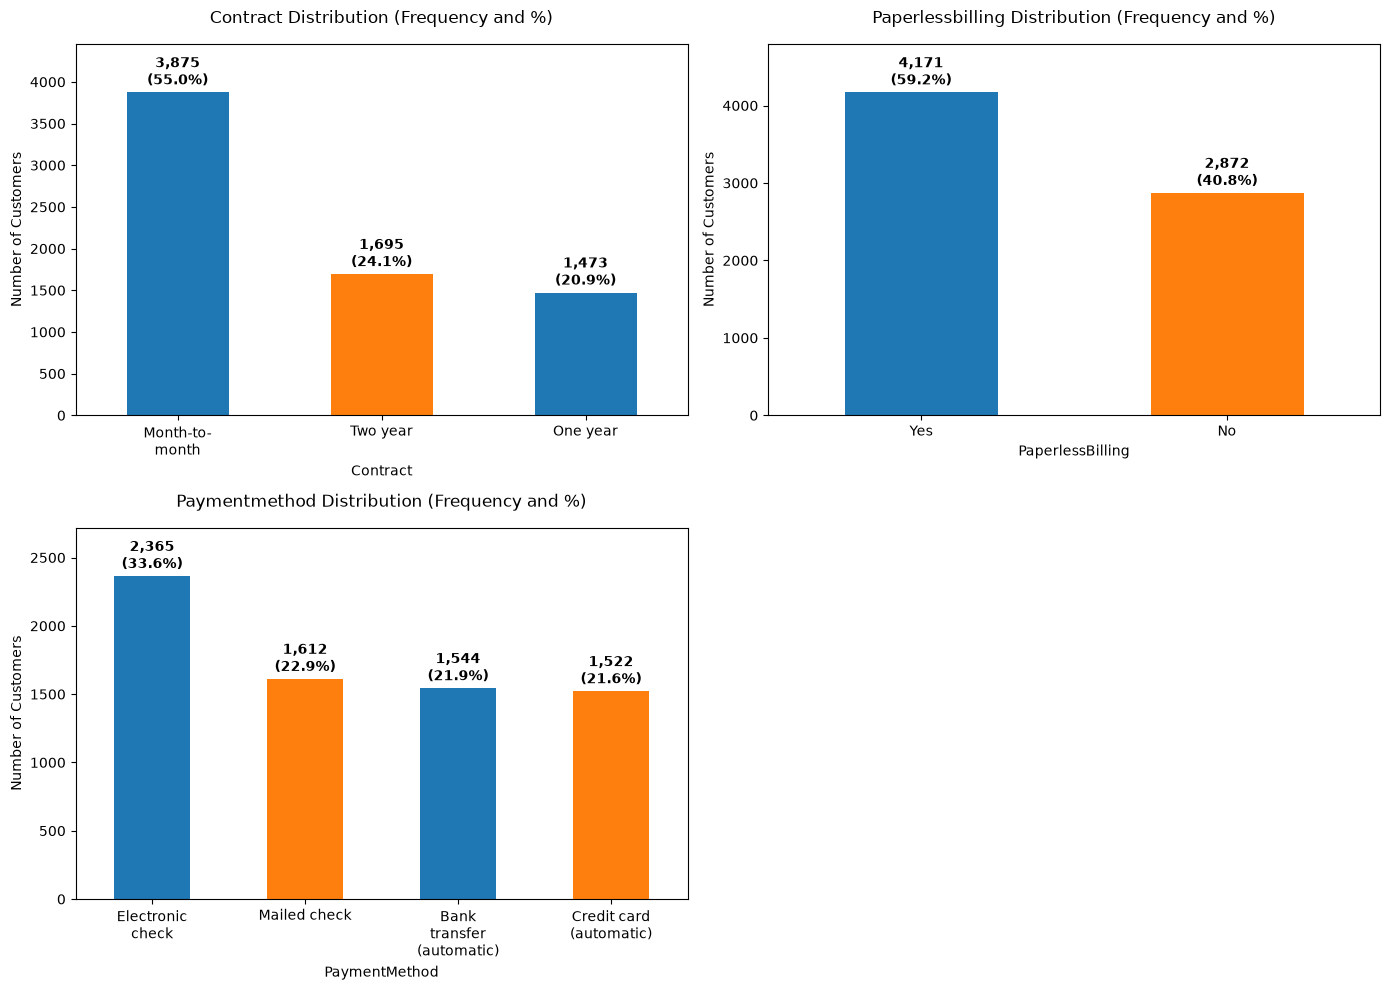

In [11]:
# Define the list of customer account features to analyze
account_features = ['tenure', 'Contract', 'PaperlessBilling', 'PaymentMethod']

# Plot distributions for the categorical account features
plot_categorical_distributions(df, account_features[1:4])

La variable `Contract` presenta una distribución concentrada principalmente en los contratos *Month-to-month*, que representan el 55.0% de los clientes (3,875). Los contratos *Two year* representan el 24.1% (1,695), mientras que *One year* concentra el 20.9% (1,473). Por lo tanto, más de la mitad de los clientes mantienen contratos mensuales, mientras que los contratos de duración fija presentan una distribución relativamente similar entre uno y dos años.

En `PaperlessBilling`, el 59.2% de los clientes (4,171) utiliza facturación electrónica, mientras que el 40.8% (2,872) no la utiliza. La distribución muestra una mayor presencia de clientes con facturación electrónica, aunque ambas categorías cuentan con un número considerable de observaciones.

Por último, `PaymentMethod` presenta una distribución más equilibrada entre sus categorías. *Electronic check* es el método de pago más frecuente, utilizado por el *33.6%* de los clientes (2,365). Le siguen *Mailed check*, con 22.9% (1,612), *Bank transfer (automatic)*, con 21.9% (1,544), y *Credit card (automatic)*, con 21.6% (1,522).

En general, no se observan categorías con una representación extremadamente reducida. Sin embargo, la predominancia de los contratos `Month-to-month` será especialmente relevante al analizar posteriormente las tasas de churn, ya que permitirá determinar si esta mayor presencia también se relaciona con una mayor proporción de abandono.

#### Distribución de `tenure`

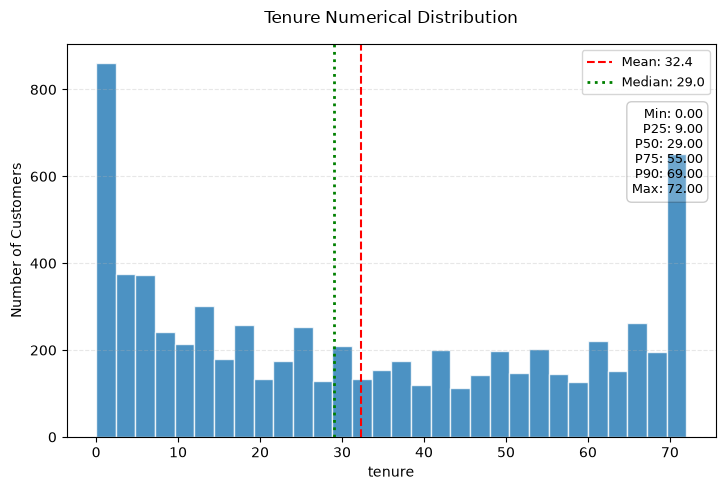

In [12]:
# Plot distributions for the numeric account features
plot_numerical_distributions(df, account_features[0:1], 30)

La variable `tenure`, que representa la antigüedad del cliente en meses, presenta una media de 32.4 meses y una mediana de 29.0 meses. La diferencia entre ambas medidas indica cierta asimetría positiva, debido a una mayor concentración de clientes con antigüedades relativamente bajas y a la presencia de clientes con una permanencia considerablemente mayor.

La distribución muestra una concentración importante de clientes con una antigüedad cercana al inicio del servicio, particularmente durante los primeros meses. También se observa un grupo numeroso de clientes con una antigüedad cercana a los 70–72 meses, correspondiente a clientes con una relación de largo plazo con la empresa.

En términos generales, `tenure` presenta una distribución amplia, con valores que abarcan prácticamente todo el periodo de permanencia disponible. No se observan indicios evidentes de valores extremos fuera de un rango razonable para esta variable.

La distribución de `tenure` resulta especialmente relevante para el análisis de churn, ya que una menor antigüedad podría estar asociada con una mayor probabilidad de abandono. Esta relación se analizará posteriormente comparando la distribución de `tenure` entre clientes que abandonaron el servicio y aquellos que permanecieron activos, además de aplicar una prueba estadística apropiada para determinar si las diferencias observadas son estadísticamente significativas.

### 6.2 Tasa de abandono en variables de cuenta

#### Tasa de abandono de `Contract`, `PaperlessBilling` y `PaymentMethod`

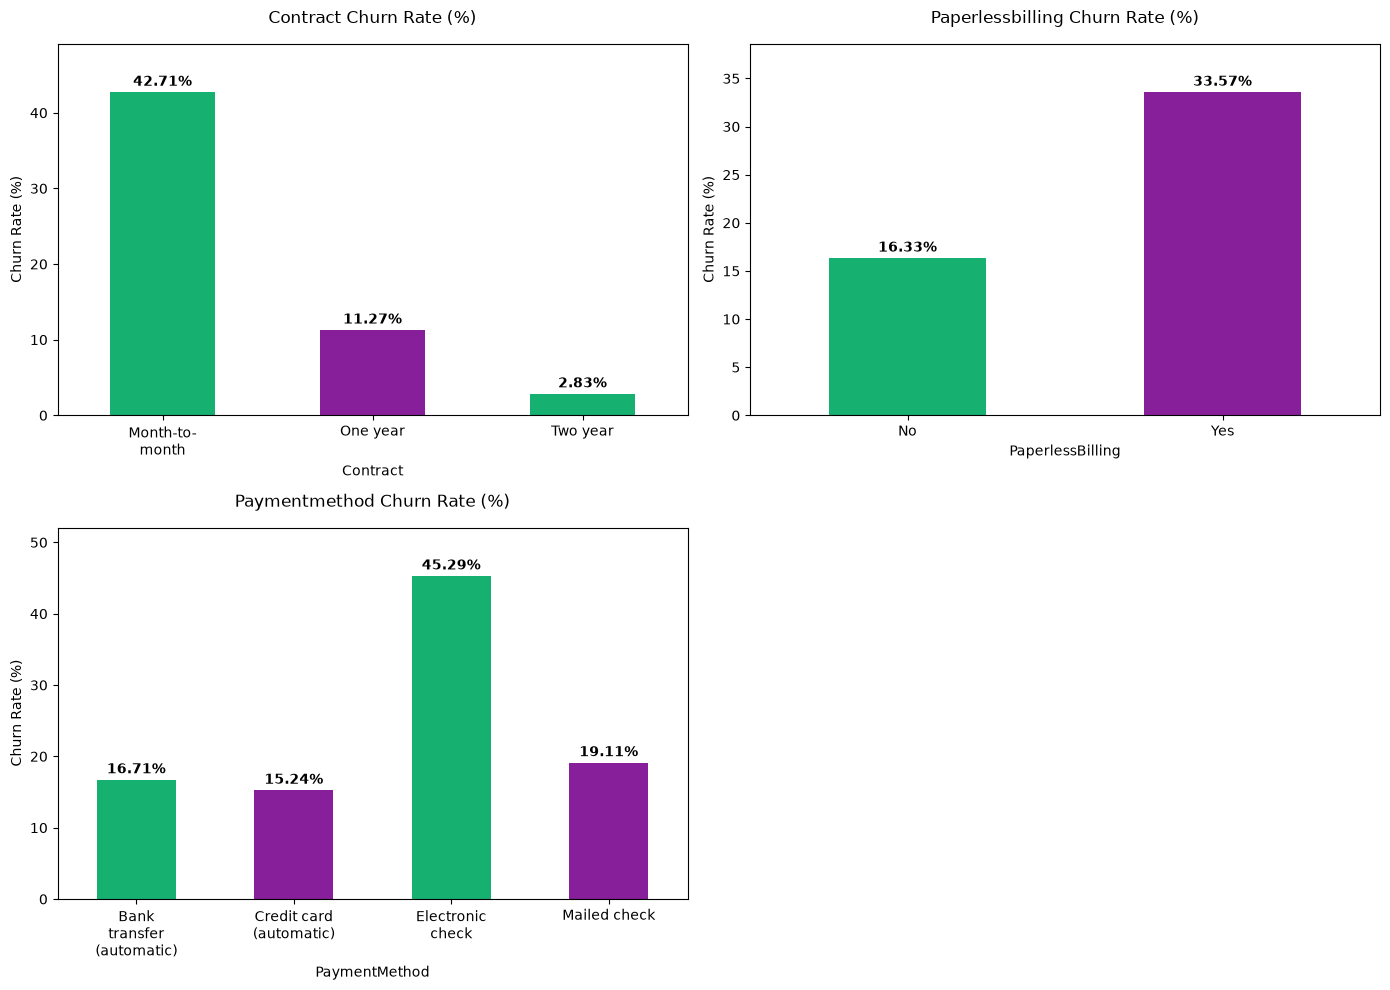

In [13]:
# Plot churn rates for the categorical account features
plot_categorical_churn_rates(df, account_features[1:4], "Churn_bool")

La variable `Contract` presenta diferencias marcadas en la tasa de abandono entre sus categorías. Los clientes con contratos *Month-to-month* presentan una tasa de churn de 42.71%, considerablemente superior a la observada en los contratos *One year* (11.27%) y *Two year* (2.83%). Esto muestra una clara diferencia en el comportamiento de abandono según el tipo de contrato, siendo los clientes con contratos mensuales el grupo con mayor proporción de churn.

En `PaperlessBilling`, los clientes que utilizan facturación electrónica (*Yes*) presentan una tasa de abandono de 33.57%, frente al 16.33% de los clientes que no utilizan este servicio (*No*). Por lo tanto, el churn observado en los clientes con facturación electrónica es aproximadamente el doble que el de aquellos que no la utilizan.

En cuanto a `PaymentMethod`, se observan diferencias importantes entre los métodos de pago. Los clientes que utilizan *Electronic check* presentan la tasa de abandono más alta, con 45.29%. Le siguen *Mailed check*, con 19.11%, *Bank transfer (automatic)*, con 16.71%, y *Credit card (automatic)*, con 15.24%.

En conjunto, `Contract` y `PaymentMethod` presentan las diferencias más pronunciadas en las tasas de abandono dentro de este grupo de variables. En particular, los clientes con contratos *Month-to-month* y aquellos que utilizan *Electronic check* muestran una proporción de churn considerablemente mayor que las demás categorías.

Estas diferencias son descriptivas y no permiten establecer por sí solas que el tipo de contrato, la facturación electrónica o el método de pago sean la causa del abandono. En la siguiente etapa se utilizarán pruebas estadísticas para evaluar si las asociaciones observadas presentan evidencia estadística y determinar su magnitud.

#### Tasa de abandono de `tenure`

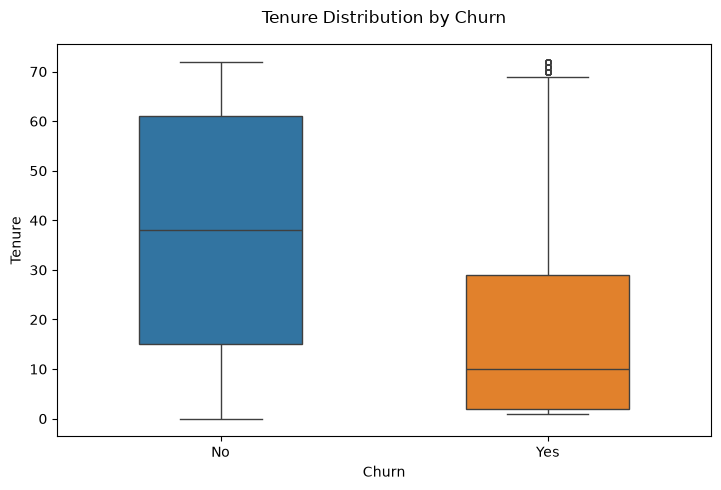

In [14]:
# Plot tenure distribution by churn
plot_continuous_by_categorical(df, account_features[0:1], 'Churn')

La distribución de `tenure` muestra diferencias claras entre los clientes que permanecieron en el servicio y aquellos que lo abandonaron. Los clientes que permanecieron (`Churn = No`) presentan una antigüedad media de alrededor de 37 meses y una mediana de 38 meses, mientras que los clientes que abandonaron (`Churn = Yes`) tienen una antigüedad media considerablemente menor, de 18.0 meses, y una mediana de apenas 10 meses.

La diferencia también se observa en los cuartiles. El 50% de los clientes que permanecieron tiene una antigüedad de entre 15 y 61 meses, mientras que para los clientes que abandonaron, el 50% central se encuentra aproximadamente entre 2 y 29 meses.

En particular, la mediana de `tenure` para los clientes que abandonaron es de solo 10 meses, frente a 38 meses para quienes permanecieron. Esto sugiere una concentración considerablemente mayor de abandono entre clientes con una relación relativamente reciente con la empresa.

Aunque ambos grupos presentan valores que alcanzan los 72 meses, la distribución indica una clara diferencia en la antigüedad entre ambos grupos. Por lo tanto, `tenure` parece ser una variable potencialmente relevante para la predicción de `Churn`.

A continuación se calculará la tasa de abandono por rangos de antigüedad. Para ello, la variable se agrupará en intervalos de 12 meses, permitiendo observar cómo varía el porcentaje de clientes que abandonan el servicio a medida que aumenta su tiempo de permanencia. 

In [15]:
# Define interval boundaries for customer tenure (in months)
bins = [-1, 12, 24, 36, 48, 60, 72]

# Define text labels for each tenure range
labels = ["0-12", "13-24", "25-36", "37-48", "49-60", "61-72"]

# Segment the 'tenure' column into ranges and create a new categorical feature
df['tenure_group'] = pd.cut(df['tenure'],
                           bins=bins,
                           labels=labels)

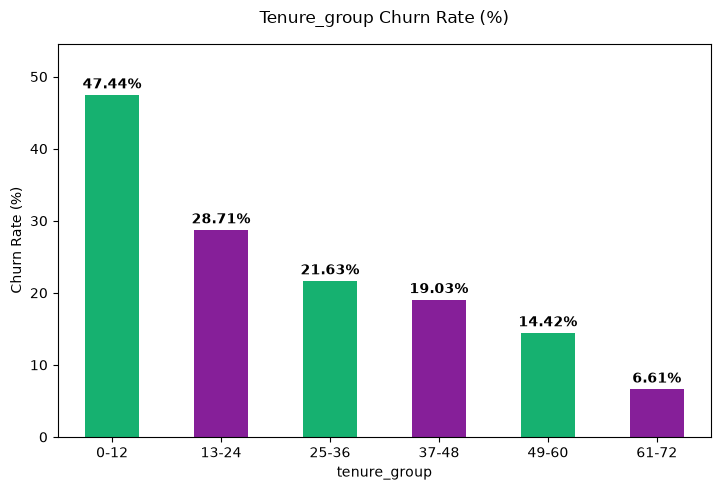

In [16]:
# Plot churn rates for tenure groups
plot_categorical_churn_rates(df, ['tenure_group'], "Churn_bool")

La tasa de abandono muestra una tendencia claramente descendente a medida que aumenta la antigüedad del cliente. Los clientes con una permanencia de entre 0-12 meses presentan la tasa de churn más alta, con 47.44%, lo que significa que prácticamente uno de cada dos clientes de este grupo abandonó el servicio.

La tasa disminuye progresivamente en los siguientes rangos: 28.71% para 13-24 meses, 21.63% para 25-36 meses y 19.03% para 37-48 meses. Para los clientes con una antigüedad de 49-60 meses, el churn se reduce a 14.42%, mientras que aquellos con 61-72` meses presentan la tasa más baja, con apenas 6.61%.

En conjunto, se observa una relación negativa entre la antigüedad y la tasa de abandono: los clientes con menor permanencia presentan una proporción considerablemente mayor de churn, mientras que el abandono disminuye entre los clientes con relaciones más prolongadas con la empresa.

Este patrón refuerza el comportamiento observado en la distribución de `tenure` según `Churn` y sugiere que la antigüedad podría ser una variable relevante para la predicción del abandono. Sin embargo, al igual que en los análisis anteriores, esta relación es descriptiva y no implica por sí misma una relación causal.

### 6.3 Análisis estádistico de variables de cuenta

En esta sección se complementarán los hallazgos obtenidos mediante el análisis descriptivo y las tasas de abandono con pruebas estadísticas, con el objetivo de determinar si las diferencias observadas entre los grupos presentan evidencia estadística de asociación con `Churn`.

Debido a que las variables de este grupo presentan diferentes tipos de datos, la prueba utilizada dependerá de la naturaleza de cada variable:

- Para las variables categóricas (`Contract`, `PaperlessBilling` y `PaymentMethod`) se utilizará la prueba Chi-cuadrado de independencia, acompañada de Cramér's V para evaluar la magnitud de la asociación.
- Para la variable numérica continua `tenure` se utilizará la prueba U de Mann-Whitney, con el objetivo de determinar si la distribución de la antigüedad difiere significativamente entre los clientes que abandonaron el servicio y aquellos que permanecieron. Como medida complementaria, se podrá utilizar un tamaño del efecto para cuantificar la magnitud de esta diferencia.

Para las variables categóricas, las hipótesis serán:

$$
H_0: \text{La variable y Churn son independientes.}
$$

$$
H_1: \text{Existe una asociación entre la variable y Churn.}
$$

En el caso de `tenure`, las hipótesis serán:

$$
H_0: \text{La distribución de tenure es igual entre ambos grupos de Churn.}
$$

$$
H_1: \text{La distribución de tenure es diferente entre ambos grupos de Churn.}
$$

El objetivo no será únicamente determinar si las diferencias son estadísticamente significativas, sino también evaluar la magnitud de las asociaciones o diferencias observadas, evitando interpretar una significancia estadística como evidencia de una relación fuerte o causal.

#### Análisis de `Contract`, `PaperlessBilling` y `PaymentMethod`

In [17]:
# Perform Chi-square test to analyze relationship between categorical account features and churn
statistical_results = chi_square_analysis(
    df=df,
    features= account_features[1:4],
    target="Churn_bool"
)

# Print results
statistical_results


,Variable,Chi-Square,p-value,Cramer's V,Asociación
0,Contract,1184.596572,5.863038e-258,0.410116,Moderada
1,PaperlessBilling,258.277649,4.073355e-58,0.191498,Baja
2,PaymentMethod,648.142327,3.682355e-140,0.303359,Moderada


Los resultados muestran evidencia estadísticamente significativa de una asociación entre las tres variables categóricas analizadas y `Churn`, ya que en todos los casos se obtuvieron valores de p-value considerablemente inferiores a 0.05. Por lo tanto, se rechaza la hipótesis nula de independencia para cada una de las variables.

La variable `Contract` presenta la asociación más fuerte del grupo, con un Cramér's V de 0.410, clasificada como una asociación moderada. Además, presenta un valor de Chi-cuadrado de 1184.60 y un p-value de aproximadamente $5.86 \times 10^{-258}$, proporcionando evidencia estadística muy fuerte de que el tipo de contrato está asociado con el churn.

`PaymentMethod` también presenta una asociación moderada, con un Cramér's V de 0.303 y un p-value de aproximadamente $3.68 \times 10^{-140}$. Esto indica que existe una relación estadísticamente significativa entre el método de pago utilizado y el abandono del servicio, aunque la magnitud de la asociación es menor que la observada para `Contract`.

Por otro lado, `PaperlessBilling` presenta una asociación baja, con un Cramér's V de 0.191. A pesar de que la magnitud de la asociación es menor, el p-value de aproximadamente $4.07\times 10^{-58}$ indica que existe evidencia estadística suficiente para rechazar la hipótesis de independencia.

Es importante distinguir entre **significancia estadística y magnitud de la asociación**. Los tres p-values son extremadamente pequeños, pero esto no significa que las tres variables tengan la misma relevancia: Cramér's V permite observar que la fuerza de la asociación es considerablemente mayor para `Contract` y `PaymentMethod` que para `PaperlessBilling`.

En conjunto, los resultados sugieren que las variables relacionadas con las condiciones de contratación y los métodos de pago presentan asociaciones relevantes con el abandono. `Contract` destaca como la variable con mayor magnitud de asociación dentro de este grupo, seguida de `PaymentMethod` y, finalmente, `PaperlessBilling`.


#### Análisis de `tenure`

Como se mencionó anteriormente, debido a que `tenure` es una variable numérica continua, se utilizará la prueba U de Mann-Whitney para comparar su distribución entre los clientes que permanecieron en el servicio y aquellos que lo abandonaron.

La prueba permitirá determinar si existe evidencia estadística de una diferencia entre ambos grupos. Las hipótesis planteadas son:

$$
H_0: \text{La distribución de tenure es igual entre ambos grupos de Churn.}
$$

$$
H_1: \text{La distribución de tenure es diferente entre ambos grupos de Churn.}
$$

Además del p-value obtenido mediante la prueba, se calculará la correlación biserial de rangos (Rank-biserial correlation, $r_{rb}$) como medida del tamaño del efecto, con el objetivo de cuantificar la magnitud de la diferencia observada entre ambos grupos.

A diferencia de las variables categóricas, donde se utilizó Cramér's V para evaluar la magnitud de la asociación, en el caso de `tenure` se utilizará una medida de tamaño del efecto específica para la prueba U de Mann-Whitney. La magnitud se interpretará utilizando los siguientes puntos de corte como referencia:

| $\|r_{rb}\|$ | Interpretación |
|---:|---|
| < 0.10 | Muy pequeño |
| 0.10 – < 0.30 | Pequeño |
| 0.30 – < 0.50 | Moderado |
| ≥ 0.50 | Grande |

Esta medida permitirá complementar la significancia estadística y distinguir entre una diferencia estadísticamente significativa y una diferencia con una magnitud relevante.

In [18]:
# Perform Mann-Whitney U test for numerical account features
statistical_results_tenure = mann_whitney_analysis(
    df=df,
    features=["tenure"],
    target="Churn_bool"
)

# Print results
statistical_results_tenure

,Variable,U Statistic,p-value,Rank-biserial r,Effect Size
0,tenure,7154668.0,2.419636e-208,0.479734,Moderado


La prueba U de Mann-Whitney muestra una diferencia estadísticamente significativa en la distribución de `tenure` entre los clientes que permanecieron en el servicio y aquellos que lo abandonaron. El estadístico obtenido fue U = 7,154,668 y el p-value = $2.42 \times 10^{-208}$, considerablemente inferior al nivel de significancia de 0.05. Por lo tanto, se rechaza la hipótesis nula de que ambas distribuciones sean iguales.

Además, la correlación biserial de rangos ($r_{rb}$) fue de 0.480, lo que corresponde a un tamaño del efecto moderado según los criterios establecidos. Esto indica que la diferencia observada en `tenure` entre ambos grupos no solo es estadísticamente significativa, sino que también presenta una magnitud relevante.

Este resultado es consistente con los análisis descriptivos realizados anteriormente, donde los clientes que abandonaron el servicio presentaron una antigüedad considerablemente menor que aquellos que permanecieron. En conjunto, la evidencia sugiere que `tenure` es una variable potencialmente importante para la predicción de `Churn`.

## 7. Análisis de Variables de Servicios Contratados

En esta sección se analizará la relación entre los servicios contratados por los clientes y el abandono del servicio (`Churn`).

El objetivo es identificar si determinados servicios presentan diferencias en las tasas de abandono y determinar si su contratación podría aportar información relevante para la predicción del churn.

Las variables que se analizarán corresponden a los principales servicios incluidos en el dataset:

- `PhoneService`: indica si el cliente cuenta con servicio telefónico.
- `MultipleLines`: indica si el cliente cuenta con múltiples líneas telefónicas.
- `InternetService`: tipo de servicio de internet contratado.
- `OnlineSecurity`: indica si el cliente cuenta con servicio de seguridad en línea.
- `OnlineBackup`: indica si el cliente cuenta con respaldo de información en línea.
- `DeviceProtection`: indica si el cliente cuenta con protección para sus dispositivos.
- `TechSupport`: indica si el cliente cuenta con soporte técnico.
- `StreamingTV`: indica si el cliente utiliza el servicio de streaming de televisión.
- `StreamingMovies`: indica si el cliente utiliza el servicio de streaming de películas.

Al igual que en los grupos anteriores, primero se analizará la distribución de las categorías y posteriormente las tasas de abandono para identificar posibles diferencias entre los distintos perfiles de clientes.

Finalmente, se aplicarán pruebas estadísticas de asociación, utilizando la prueba Chi-cuadrado de independencia y **Cramér's V** para evaluar, respectivamente, la significancia estadística y la magnitud de la asociación entre cada variable y `Churn`.

In [19]:
# Define the list of service features to analyze
service_features = [
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

### 7.1 Distribución de variables de servicios

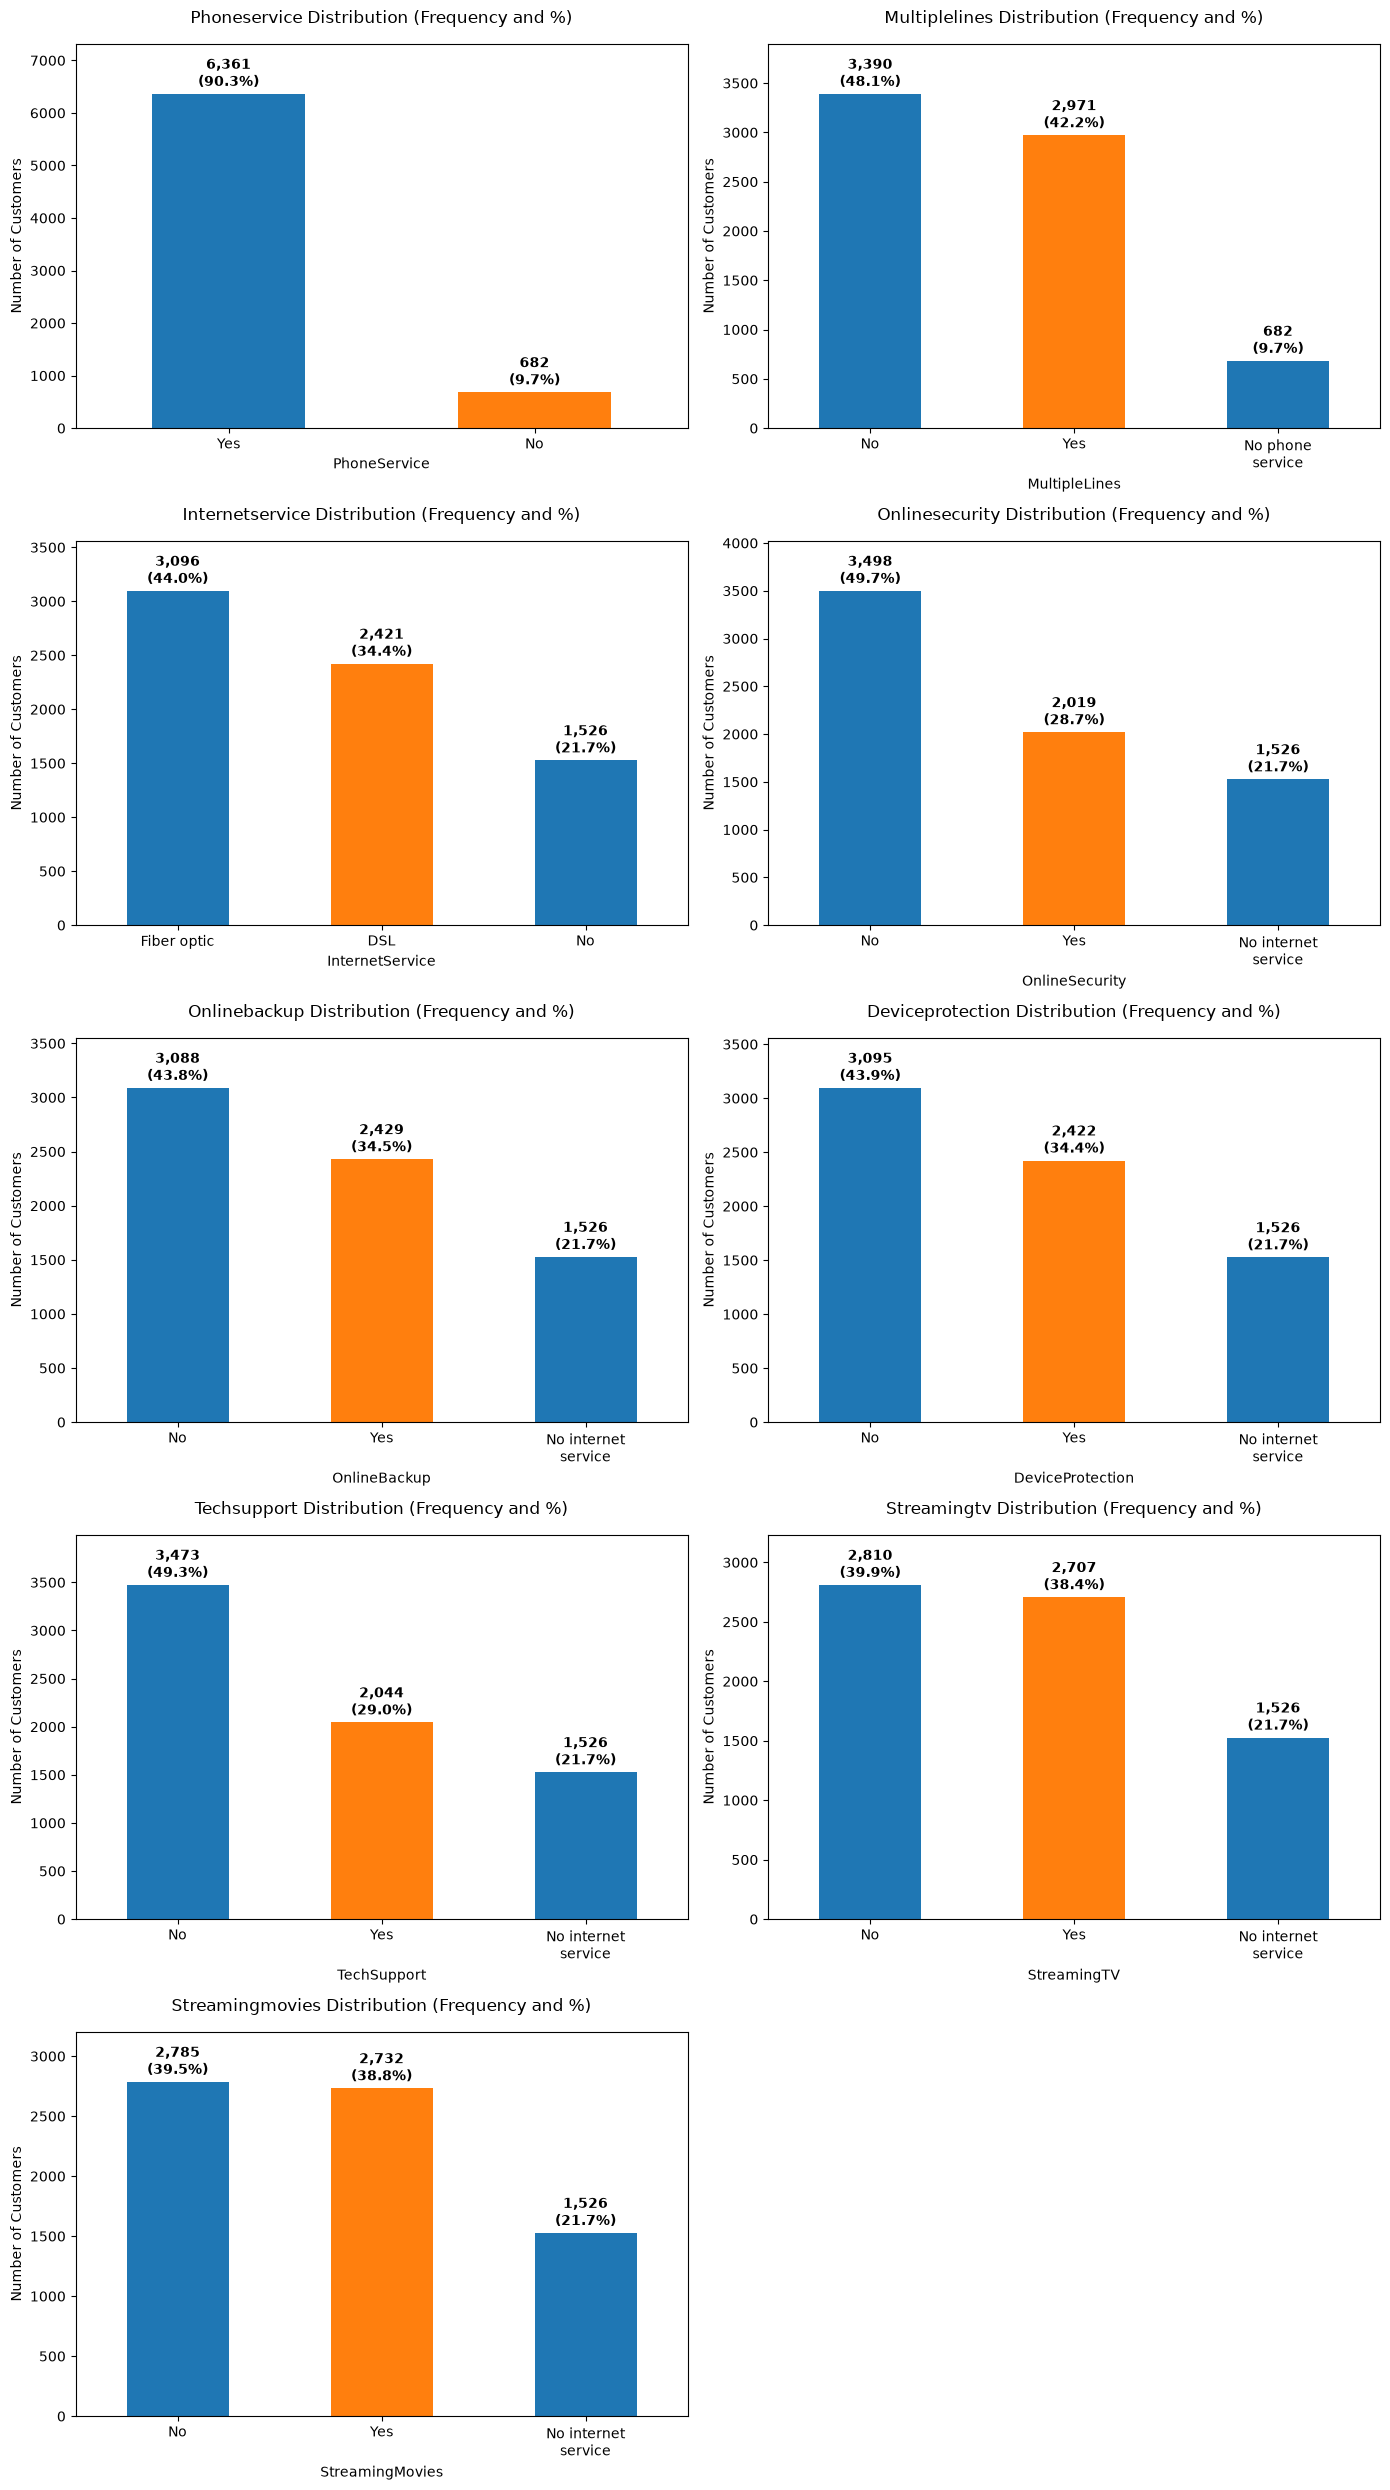

In [20]:
# Plot distributions for the services features
plot_categorical_distributions(df, service_features)


La distribución de las variables de servicios muestra lo siguiente:

- La mayoría de los clientes cuenta con servicio telefónico (`PhoneService`), presente en el 90.3% de los casos, mientras que únicamente el 9.7% no cuenta con este servicio. Esta distribución indica que `PhoneService` presenta un fuerte desbalance entre sus categorías.

- En `MultipleLines`, el 48.1% de los clientes no cuenta con múltiples líneas, mientras que el 42.2% sí las tiene. El 9.7% restante corresponde a clientes sin servicio telefónico, para quienes esta variable no aplica. Las dos categorías principales presentan proporciones relativamente similares.

- `InternetService` presenta una distribución más diferenciada. El 43.96% de los clientes utiliza fibra óptica, el 34.37% cuenta con servicio DSL y el 21.67% no tiene servicio de internet. La fibra óptica representa la categoría más frecuente dentro de esta variable.

- Para los servicios adicionales relacionados con internet, como `OnlineSecurity`, `OnlineBackup`, `DeviceProtection` y `TechSupport`, se observa un patrón similar. En todos los casos, el 21.7% de los clientes corresponde a la categoría *No internet service*, mientras que entre los clientes con servicio de internet predominan aquellos que no cuentan con el servicio adicional analizado.

    - En `OnlineSecurity`, el 49.7% de los clientes se encuentra en la categoría *No*, frente al 28.7% que cuenta con este servicio. Para `TechSupport` se observa un comportamiento similar, con 49.3% de clientes sin soporte técnico y 29.0% con el servicio.

    - `OnlineBackup` y `DeviceProtection` presentan distribuciones ligeramente más equilibradas. En ambos casos, alrededor del 43.8% de los clientes no cuenta con el servicio, mientras que aproximadamente el 34.4% sí lo tiene.

    - Finalmente, `StreamingTV` y `StreamingMovies` presentan las distribuciones más equilibradas dentro de este grupo. En ambos casos, las categorías *Yes* y *No* representan aproximadamente entre el 38% y 40% de los clientes.

En conjunto, las variables de servicios presentan diferentes niveles de concentración entre sus categorías. Destacan el fuerte predominio de la categoría *Yes* en `PhoneService` y la presencia recurrente de la categoría *No internet service* en las variables dependientes del servicio de internet. Estas características deberán considerarse al analizar posteriormente las tasas de abandono, ya que una distribución desigual puede influir en la interpretación de las diferencias observadas entre categorías.

### 7.2 Tasa de abandono en variables de servicios

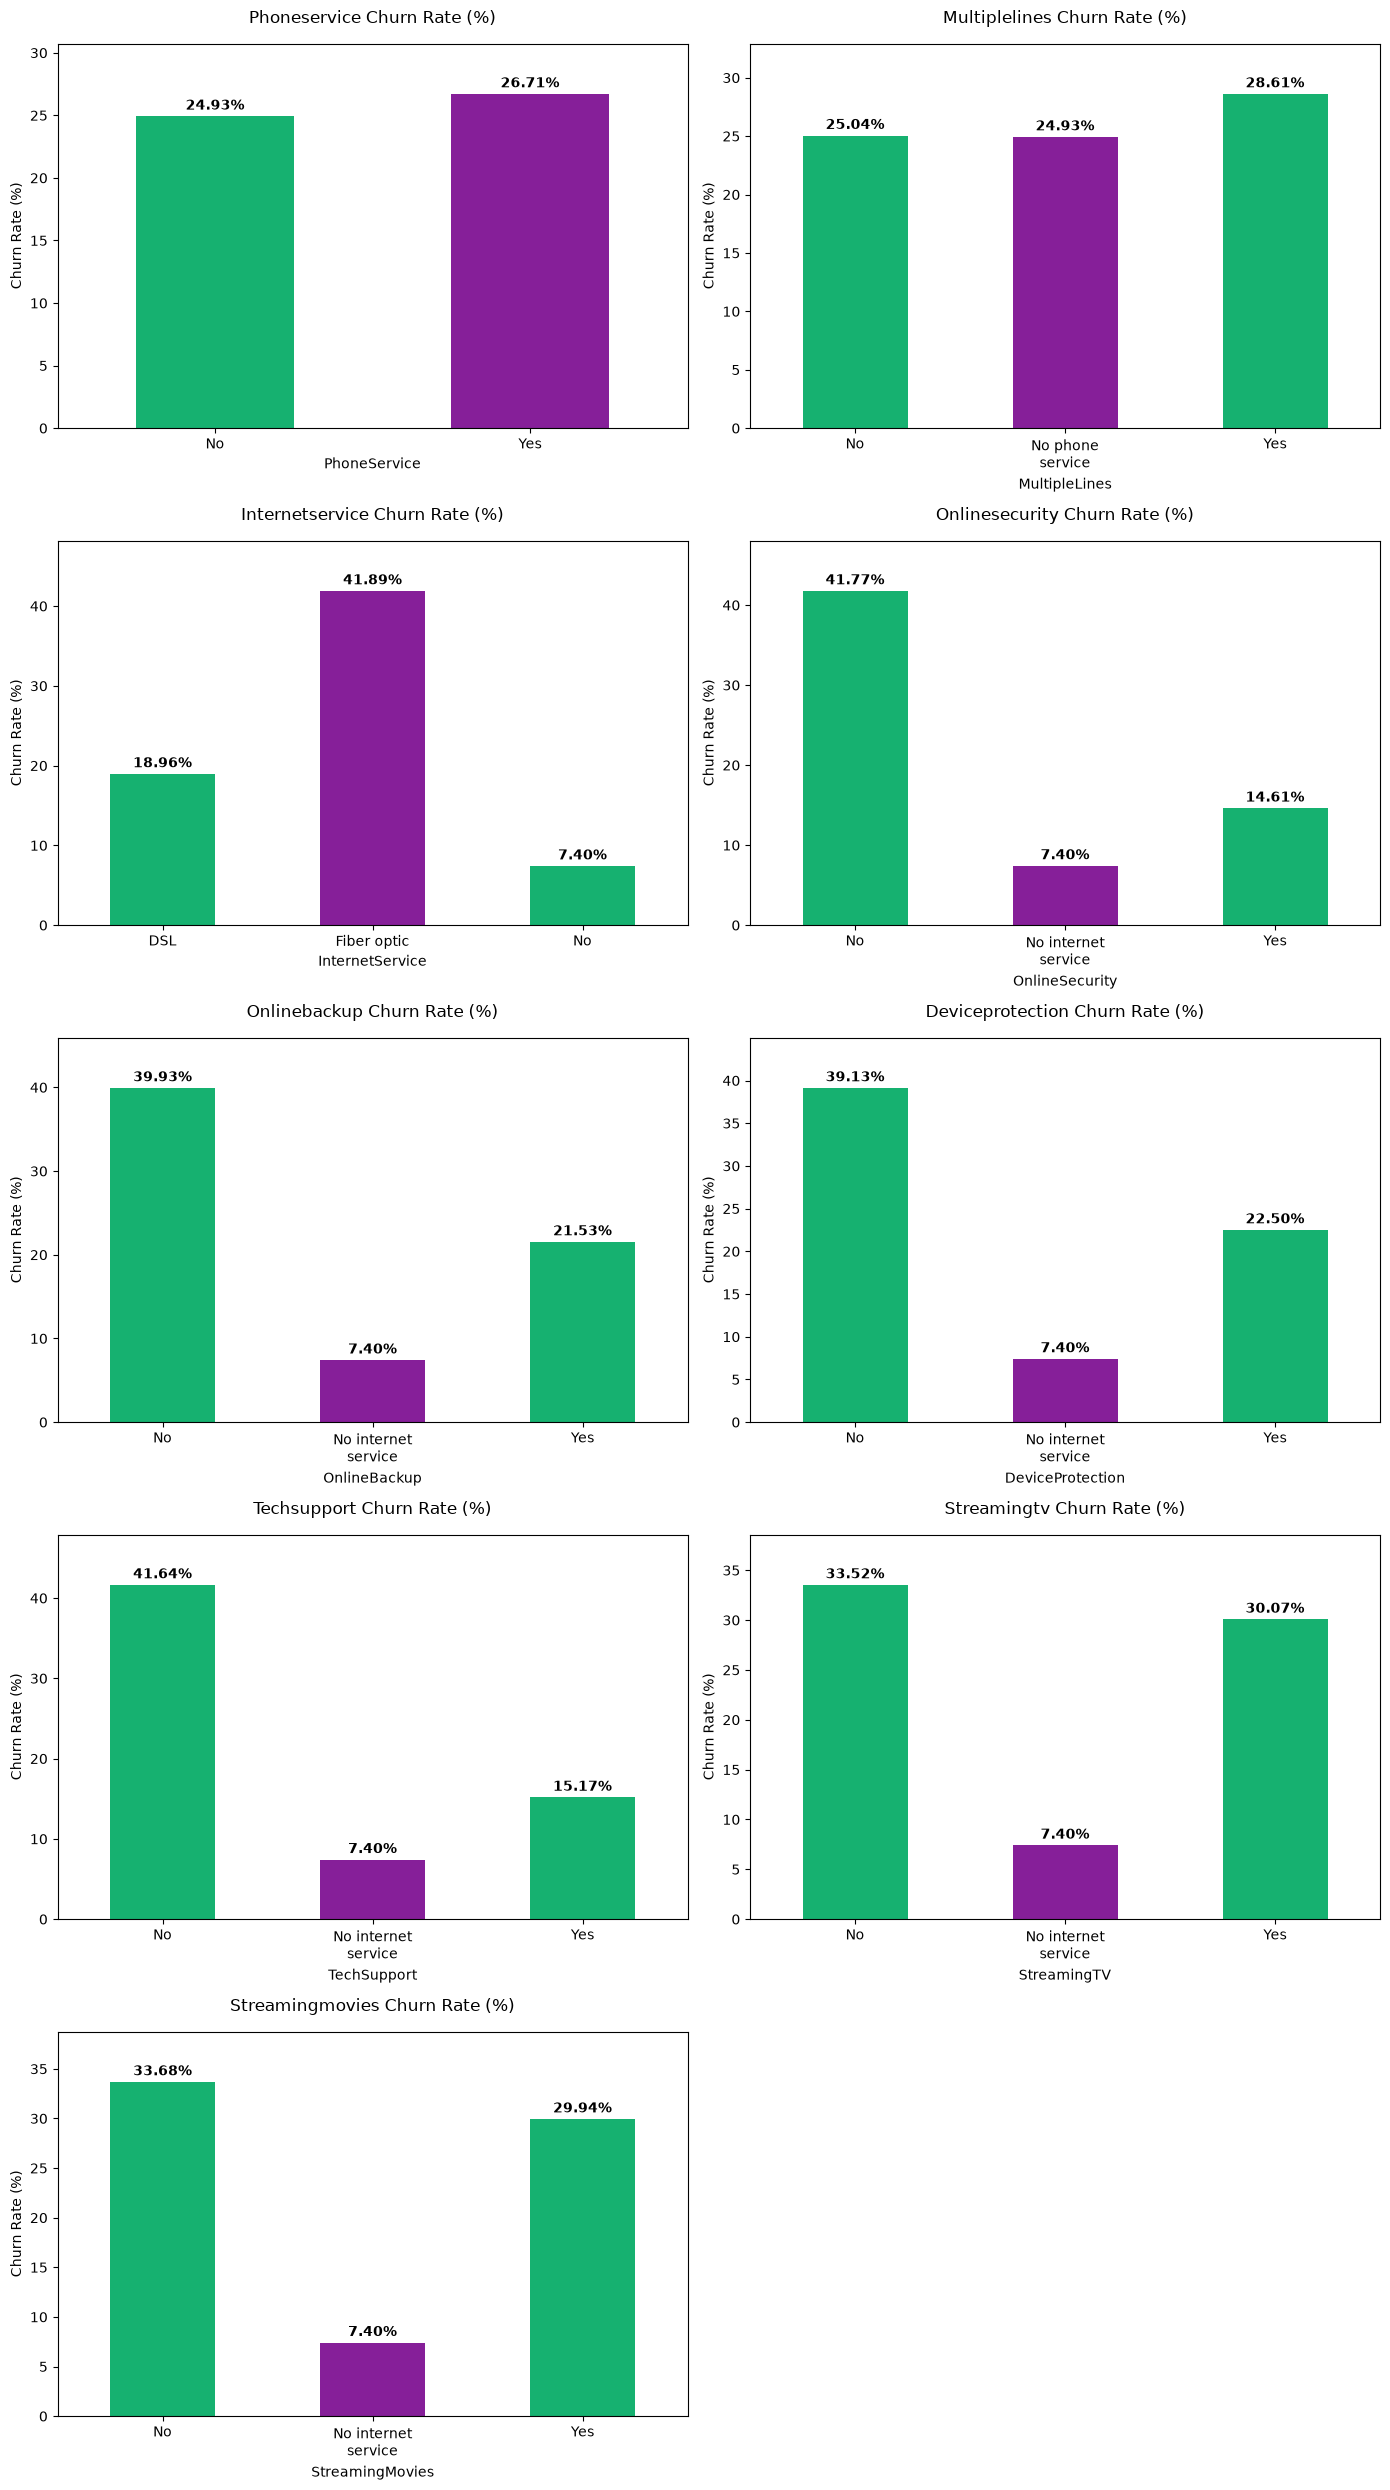

In [21]:
plot_categorical_churn_rates(df, service_features, 'Churn_bool')

En el análisis de las tasas de abandono en las variables de servicios podemos observar:

- En `PhoneService` las tasas de abandono son muy similares entre ambas categorías: *Yes* presenta un churn rate de 26.71%, mientras que *No* alcanza 24.93%. La diferencia es pequeña, por lo que, a nivel descriptivo, no se observa un patrón claramente diferenciado de abandono asociado con esta variable.

- En `MultipleLines`, los clientes en la categoría *Yes* presentan una tasa de abandono de 28.61%, superior a las categorías *No* (25.04%) y *No phone service* (24.93%). Aunque existe una diferencia descriptiva, esta deberá contrastarse posteriormente mediante una prueba estadística para determinar si la asociación es significativa.

- En `InternetService` se observa una diferencia considerable entre las categorías. *Fiber optic* presenta una tasa de abandono de 41.89%, mientras que *DSL* alcanza 18.96% y *No* únicamente 7.40%. Esta diferencia sugiere que el tipo de servicio de internet podría estar fuertemente relacionado con el churn y constituye una variable de especial interés para el análisis posterior.

- `OnlineSecurity` presenta una diferencia marcada entre sus categorías. Los clientes en *No* tienen una tasa de abandono de 41.77%, frente a 14.61% para *Yes* y 7.40% para *No internet service*. Descriptivamente, los clientes que cuentan con este servicio presentan una tasa de abandono considerablemente menor.

- En `OnlineBackup` se observa un patrón similar. La categoría *No* presenta una tasa de abandono de 39.93%, mientras que *Yes* alcanza 21.53% y *No internet service* 7.40%. La diferencia entre quienes cuentan y no cuentan con el servicio sugiere una posible relación con la retención.

- `DeviceProtection` muestra también una diferencia importante. La tasa de abandono es de 39.13% para *No*, frente a 22.50% para *Yes* y 7.40% para *No internet service*. Nuevamente, los clientes que cuentan con el servicio presentan una menor tasa de abandono.

- En `TechSupport` se observa uno de los contrastes más pronunciados. La categoría *No* presenta una tasa de abandono de 41.64%, mientras que *Yes* alcanza 15.17% y *No internet service* 7.40%. Esto sugiere que la contratación de soporte técnico podría estar asociada con una mayor retención de clientes.

- `StreamingTV` presenta una diferencia considerablemente menor. La categoría *No* registra una tasa de abandono de 33.52%, mientras que *Yes* presenta 30.07% y *No internet service* 7.40%. Aunque existe una diferencia entre las categorías relacionadas con el servicio de streaming, esta es relativamente pequeña en comparación con otras variables del grupo.

- Finalmente, `StreamingMovies` presenta un comportamiento prácticamente equivalente al observado en `StreamingTV`. La tasa de abandono es de 33.68% para *No*, 29.94% para *Yes* y 7.40% para *No internet service*. La diferencia entre las categorías *No* y *Yes* es relativamente reducida.

En conjunto, las mayores diferencias descriptivas se observan en `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection` y `TechSupport`. Por el contrario, `PhoneService`, `MultipleLines`, `StreamingTV` y `StreamingMovies` presentan diferencias más pequeñas entre las categorías principales.

Estas observaciones serán contrastadas mediante el análisis estadístico posterior para determinar cuáles de estas diferencias representan asociaciones estadísticamente significativas con `Churn` y cuál es la magnitud de dichas asociaciones.

### 7.3 Análisis estadístico de variables de servicios

En esta sección se complementará el análisis descriptivo realizado anteriormente mediante pruebas estadísticas, con el objetivo de determinar si las diferencias observadas en las tasas de abandono entre las categorías de las variables de servicios presentan evidencia estadística de una asociación con `Churn`.

Dado que todas las variables de este grupo son categóricas, se utilizará la prueba Chi-cuadrado de independencia para evaluar si existe una relación estadísticamente significativa entre cada variable y `Churn`.

Las hipótesis planteadas para cada variable son:

$$
H_0: \text{La variable y Churn son independientes.}
$$

$$
H_1: \text{Existe una asociación entre la variable y Churn.}
$$

Además del p-value, se calculará Cramér's V como medida del tamaño de la asociación. Esto permitirá complementar la significancia estadística con una medida de magnitud, evitando interpretar un p-value significativo como evidencia de una asociación necesariamente fuerte.

Los resultados permitirán identificar qué variables de servicios presentan una asociación estadísticamente significativa con el abandono y cuáles muestran una mayor magnitud de asociación, proporcionando evidencia adicional para determinar las variables candidatas que serán consideradas en las etapas posteriores de Feature Engineering y Modelado.

In [22]:
# Perform Chi-square test to analyze relationship between categorical account features and churn
statistical_results = chi_square_analysis(
    df=df,
    features= service_features,
    target="Churn_bool"
)

# Print results
statistical_results

,Variable,Chi-Square,p-value,Cramer's V,Asociación
0,PhoneService,0.915033,3.387825e-01,0.011398,Muy baja
1,MultipleLines,11.330441,3.464383e-03,0.040109,Muy baja
2,InternetService,732.309590,9.571788e-160,0.322455,Moderada
3,OnlineSecurity,849.998968,2.661150e-185,0.347400,Moderada
4,OnlineBackup,601.812790,2.079759e-131,0.292316,Baja
5,DeviceProtection,558.419369,5.505219e-122,0.281580,Baja
6,TechSupport,828.197068,1.443084e-180,0.342916,Moderada
7,StreamingTV,374.203943,5.528994e-82,0.230502,Baja
8,StreamingMovies,375.661479,2.667757e-82,0.230951,Baja


Los resultados del análisis estadístico son consistentes, en términos generales, con los patrones observados previamente mediante las tasas de abandono. La mayoría de las variables presentan un p-value inferior a 0.05, por lo que existe evidencia estadística para rechazar la hipótesis nula de independencia entre estas variables y `Churn`.

- `PhoneService` es la única variable que no presenta evidencia estadística de asociación con `Churn`, con un p-value de 0.339 y un Cramér's V de 0.011. Por lo tanto, no se rechaza la hipótesis nula de independencia. Además, la magnitud de la asociación es muy baja, lo que coincide con las tasas de abandono observadas anteriormente, que fueron muy similares entre las categorías de esta variable.

- `MultipleLines` presenta un p-value de 0.0035, por lo que existe evidencia estadística de una asociación con `Churn`. Sin embargo, su Cramér's V es únicamente 0.040, clasificado como una asociación muy baja. Esto es importante porque, aunque la prueba estadística detecta una asociación significativa, su magnitud es mínima. La diferencia observada en las tasas de abandono entre las categorías no representa una relación fuerte con el churn.

- `InternetService` presenta una de las asociaciones más importantes del grupo, con un Cramér's V de 0.322, clasificado como moderado, y un p-value extremadamente pequeño. Este resultado respalda estadísticamente las diferencias observadas en el análisis descriptivo, particularmente la elevada tasa de abandono asociada con la categoría *Fiber optic* frente a *DSL* y *No*. Por lo tanto, `InternetService` se identifica como una variable potencialmente relevante para la predicción del churn.

- `OnlineSecurity` presenta una asociación moderada con `Churn`, con un Cramér's V de 0.347 y un p-value de aproximadamente 2.66 × 10⁻¹⁸⁵. El resultado confirma estadísticamente las diferencias observadas en las tasas de abandono, donde la categoría *No* presentó una tasa considerablemente mayor que *Yes*. Por su magnitud de asociación, esta variable representa una de las variables de servicios más relevantes dentro del análisis.

- `OnlineBackup` presenta una asociación baja, con un Cramér's V de 0.292. Aunque el p-value es extremadamente pequeño, indicando evidencia estadística de asociación, la magnitud es menor que la observada para `InternetService` y `OnlineSecurity`. El resultado coincide con el análisis descriptivo, donde los clientes en la categoría *No* presentaron una tasa de abandono considerablemente mayor que aquellos en *Yes*.

- `DeviceProtection` presenta un comportamiento similar. El p-value de aproximadamente 5.51 × 10⁻¹²² indica una asociación estadísticamente significativa, mientras que el Cramér's V de 0.282 corresponde a una asociación baja. Por lo tanto, aunque existe evidencia estadística de una relación entre esta variable y `Churn`, su magnitud es moderada en comparación con las variables de servicios con mayor asociación.

- `TechSupport` presenta nuevamente una asociación moderada, con un Cramér's V de 0.343 y un p-value extremadamente pequeño. Este resultado respalda las diferencias observadas en el análisis descriptivo, donde los clientes en la categoría *No* presentaron una tasa de abandono considerablemente superior a aquellos en *Yes*. Junto con `InternetService` y `OnlineSecurity`, `TechSupport` se encuentra entre las variables de servicios con mayor asociación con el churn.

- `StreamingTV` presenta una asociación baja, con un Cramér's V de 0.231. Aunque el p-value indica una asociación estadísticamente significativa, la magnitud es menor que la observada para `InternetService`, `OnlineSecurity` y `TechSupport`. Esto es consistente con el análisis descriptivo, donde las tasas de abandono de las categorías *No* y *Yes* fueron relativamente cercanas.

- Finalmente, `StreamingMovies` presenta prácticamente el mismo comportamiento que `StreamingTV`. El p-value es extremadamente pequeño y el Cramér's V de 0.231 corresponde a una asociación baja. Por lo tanto, existe evidencia estadística de asociación con `Churn`, pero su magnitud es relativamente limitada.

En conjunto, `InternetService`, `OnlineSecurity` y `TechSupport` presentan las asociaciones de mayor magnitud dentro del grupo, todas clasificadas como moderadas. `OnlineBackup`, `DeviceProtection`, `StreamingTV` y `StreamingMovies` presentan asociaciones bajas, mientras que `MultipleLines` presenta una asociación muy baja a pesar de resultar estadísticamente significativa. `PhoneService`, por su parte, no presenta evidencia estadística suficiente de asociación con `Churn`.

Estos resultados muestran nuevamente la importancia de distinguir entre significancia estadística y magnitud de asociación. Por ejemplo, `MultipleLines` presenta un p-value inferior a 0.05, pero su Cramér's V es de apenas 0.040. En contraste, `InternetService` presenta tanto una asociación estadísticamente significativa como una magnitud moderada. Por ello, ambas medidas serán consideradas conjuntamente al determinar las variables candidatas para las siguientes etapas del proyecto.

## 8. Análisis de Variables Financieras

En esta sección se analizará la relación entre las características financieras de los clientes y el abandono del servicio (`Churn`).

El objetivo es determinar si los niveles de facturación presentan diferencias entre los clientes que abandonaron el servicio y aquellos que permanecieron, así como evaluar si estas variables podrían aportar información relevante para la predicción del churn.

Las variables que se analizarán son:

- `MonthlyCharges`: cargos mensuales del cliente.
- `TotalCharges`: cargos totales acumulados durante el periodo de permanencia del cliente.

A diferencia de los grupos anteriores, ambas variables son numéricas continuas. Por ello, el análisis se centrará inicialmente en su distribución y en las diferencias observadas entre los grupos de `Churn`.

Posteriormente, se analizarán las tasas de abandono asociadas con diferentes rangos de valores cuando resulte útil para identificar patrones de comportamiento. Finalmente, se aplicarán pruebas estadísticas apropiadas para variables numéricas con el objetivo de determinar si las diferencias observadas entre los grupos presentan evidencia estadística y evaluar la magnitud de dichas diferencias.

Los resultados permitirán determinar si el nivel de facturación y el gasto acumulado del cliente presentan patrones relevantes de abandono y si estas variables deberían considerarse candidatas para las siguientes etapas.

### 8.1 Distribución de variables financieras

In [23]:
# Define the list of financial features to analyze
financial_features = ["MonthlyCharges", "TotalCharges"]

# View financial features info
df[financial_features].info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   MonthlyCharges  7043 non-null   float64
 1   TotalCharges    7043 non-null   str    
dtypes: float64(1), str(1)
memory usage: 150.6 KB


In [24]:
# Inspect total charges for zero-tenure users
df[['tenure', 'TotalCharges']][df['tenure']==0]

,tenure,TotalCharges
488,0,
753,0,
936,0,
1082,0,
1340,0,
3331,0,
3826,0,
4380,0,
5218,0,
6670,0,


La variable `TotalCharges` se encuentra como tipo `str` debido a que existen 11 registros con valores vacíos. Los 11 registros que presentan un espacio en blanco en `TotalCharges` corresponden a clientes con *tenure = 0*. Esto indica que se trata de clientes sin antigüedad registrada y, consecuentemente, sin cargos totales acumulados disponibles en el dataset.

Por este motivo, los valores se transformaran a `NaN` durante la conversión a formato numérico. Estos registros se conservarán temporalmente y su tratamiento se definirá posteriormente de acuerdo con los requerimientos del modelado.

In [25]:
# Replace blank spaces with NaN
df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)

# Convert TotalCharges from string to numeric
df["TotalCharges"] = df["TotalCharges"].astype(float)

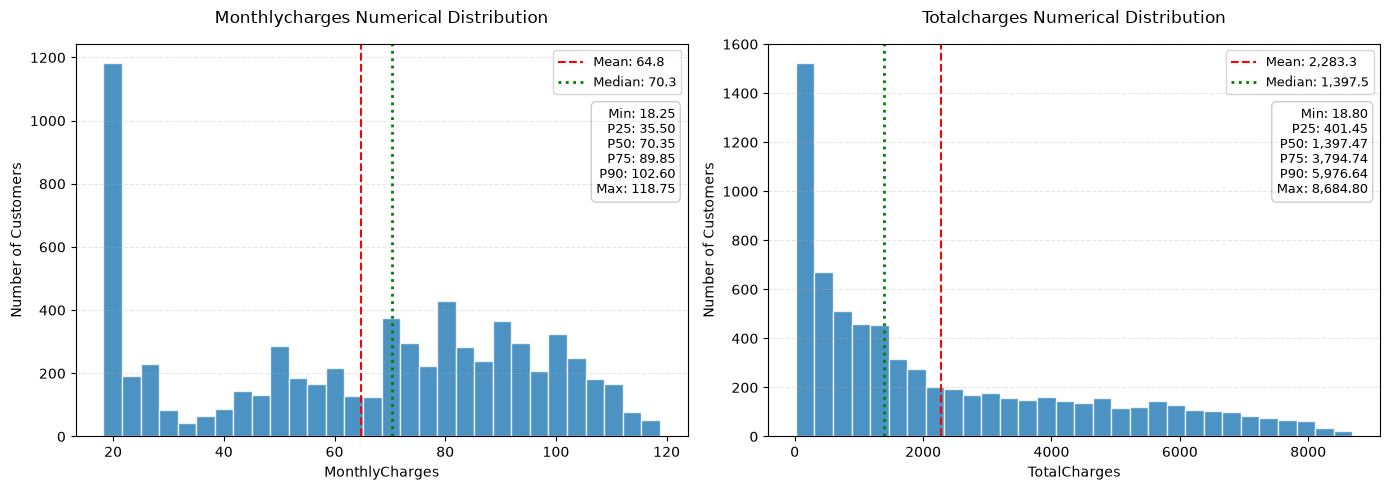

In [26]:
# Plot distributions for the numeric financial features
plot_numerical_distributions(df, financial_features, 30)

En el histograma, podemos observar que `MonthlyCharges` presenta valores entre alrededor de 18.25 y 118.75, con una media de 64.8 y una mediana de 70.3. La mediana superior a la media sugiere cierta asimetría hacia valores bajos. La mitad de los clientes presenta cargos mensuales entre 35.50 y 89.85, mientras que el 90% se encuentra por debajo de 102.60. En general, se observa una distribución relativamente amplia de los cargos mensuales, lo que permitirá evaluar posteriormente si determinados niveles de facturación están asociados con mayores tasas de abandono.

`TotalCharges` presenta una dispersión considerablemente mayor en términos relativos, con valores entre 18.80 y 8,684.80. La media es de 2,283.30, mientras que la mediana es de 1,397.50, lo que evidencia una distribución con asimetría positiva: una proporción de clientes con cargos acumulados elevados incrementa la media. El 50% de los clientes presenta cargos totales inferiores a 1,397.48, mientras que el 90% se encuentra por debajo de 5,976.64.

La diferencia entre la media y la mediana de `TotalCharges` también es consistente con la naturaleza de esta variable, ya que los cargos acumulados dependen tanto del nivel de facturación como del tiempo que el cliente ha permanecido en el servicio. Por esta razón, se espera que `TotalCharges` presente una relación importante con `tenure`, aspecto que deberá considerarse al interpretar posteriormente su relación con `Churn`.

En conjunto, ambas variables presentan suficiente variabilidad para investigar si los niveles de facturación están relacionados con el abandono. En el análisis posterior se compararán sus distribuciones entre los grupos de `Churn` y se evaluará estadísticamente la magnitud de las diferencias observadas.

### 8.2 Tasa de abandono de variables financieras

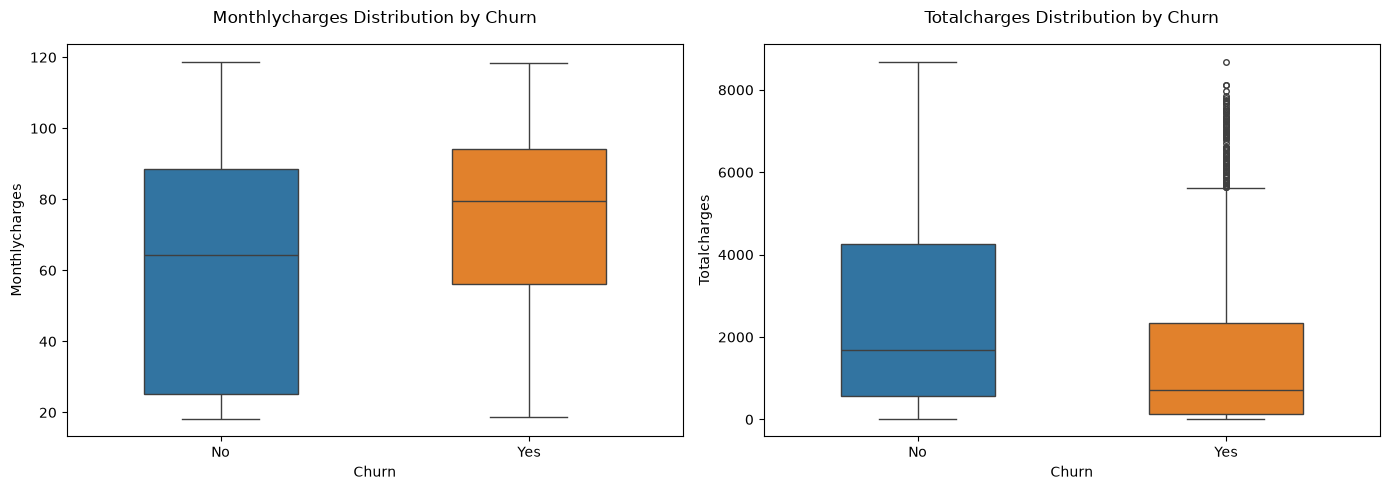

VARIABLE: MonthlyCharges
Churn       No      Yes
count  5174.00  1869.00
mean     61.27    74.44
std      31.09    24.67
min      18.25    18.85
25%      25.10    56.15
50%      64.43    79.65
75%      88.40    94.20
max     118.75   118.35

VARIABLE: TotalCharges
Churn       No      Yes
count  5163.00  1869.00
mean   2555.34  1531.80
std    2329.46  1890.82
min      18.80    18.85
25%     577.83   134.50
50%    1683.60   703.55
75%    4264.12  2331.30
max    8672.45  8684.80



In [27]:
# Plot financial features distributions by churn
plot_continuous_by_categorical(df, financial_features, 'Churn')

# Calculate summary statistics per churn group for each financial feature
for var in financial_features:
    boxplot_stats = df.groupby('Churn')[var].describe([0.25, 0.50, 0.75]).T
    print("="*30)
    print(f'VARIABLE: {var}')
    print("="*30)
    print(boxplot_stats.round(2))
    print("")

La distribución de `MonthlyCharges` entre los grupos de `Churn` presenta una diferencia clara en la distribución de los cargos mensuales entre ambos grupos. Los clientes que abandonaron el servicio presentan una media de 74.44 y una mediana de 79.65, superiores a los valores observados en los clientes que permanecieron, cuya media es de 61.27 y mediana de 64.43. En el boxplot, esto se refleja en un desplazamiento de la distribución del grupo *Yes* hacia valores de cargos mensuales más elevados.

La diferencia es especialmente visible en los primeros cuartiles: el 25% de los clientes que permanecieron presenta cargos de hasta 25.10, mientras que para los clientes que abandonaron el servicio este valor asciende a 56.15. Sin embargo, a partir de los percentiles superiores las distribuciones se aproximan, con valores máximos cercanos a 119. Esto sugiere que los cargos mensuales más elevados podrían estar asociados con una mayor probabilidad de abandono, aunque la distribución presenta una considerable superposición entre ambos grupos.

En `TotalCharges` se observa un patrón diferente. Los clientes que permanecieron en el servicio presentan valores considerablemente mayores que aquellos que abandonaron. La mediana de `TotalCharges` es de 1,683.60 para *No*, frente a 703.55 para *Yes*, mientras que las medias son de 2,555.34 y 1,531.80, respectivamente. En el boxplot, esto se manifiesta como un desplazamiento de la distribución del grupo *No* hacia valores superiores.

La diferencia también se mantiene a través de los principales percentiles. El primer cuartil es de 577.83 para los clientes que permanecieron, frente a 134.50 para quienes abandonaron, mientras que el tercer cuartil alcanza 4,264.13 y 2,331.30, respectivamente. Aunque ambos grupos presentan valores máximos similares, la mayor parte de la distribución de *Yes* se concentra en niveles considerablemente menores de cargos acumulados.

Este comportamiento es consistente con los resultados observados previamente para `tenure`, ya que los cargos acumulados dependen en gran medida del tiempo que el cliente ha permanecido en el servicio. Los clientes con menor antigüedad tienen menos tiempo para acumular cargos, por lo que la diferencia observada en `TotalCharges` no debe interpretarse automáticamente como un efecto independiente sobre el churn.

En conjunto, los boxplots muestran patrones diferenciados para ambas variables: los clientes que abandonaron presentan, en general, cargos mensuales más elevados, mientras que los clientes que permanecieron acumulan mayores cargos totales.

A continuación, se calculará la tasa de abandono por rangos de las variables `MonthlyCharges` y `TotalCharges`, con el objetivo de identificar posibles patrones en el comportamiento del churn a diferentes niveles de facturación. Para facilitar la comparación entre grupos, los valores de cada variable se dividirán en rangos. Este análisis tendrá un propósito principalmente descriptivo y permitirá complementar los patrones observados en los boxplots antes de realizar las pruebas estadísticas correspondientes.

In [28]:
# Define quartile-based interval boundaries for MonthlyCharges
monthly_bins = df["MonthlyCharges"].quantile([0, 0.25, 0.50, 0.75, 1.00]).unique()

# Define text labels for each MonthlyCharges range
monthly_labels = ["Q1", "Q2", "Q3", "Q4"]

# Segment MonthlyCharges into quartile-based groups
df["MonthlyCharges_group"] = pd.cut(
    df["MonthlyCharges"],
    bins=monthly_bins,
    labels=monthly_labels,
    include_lowest=True
)

# Define quartile-based interval boundaries for TotalCharges
total_bins = df["TotalCharges"].quantile([0, 0.25, 0.50, 0.75, 1.00]).unique()

# Define text labels for each TotalCharges range
total_labels = ["Q1", "Q2", "Q3", "Q4"]

# Segment TotalCharges into quartile-based groups
df["TotalCharges_group"] = pd.cut(
    df["TotalCharges"],
    bins=total_bins,
    labels=total_labels,
    include_lowest=True
)

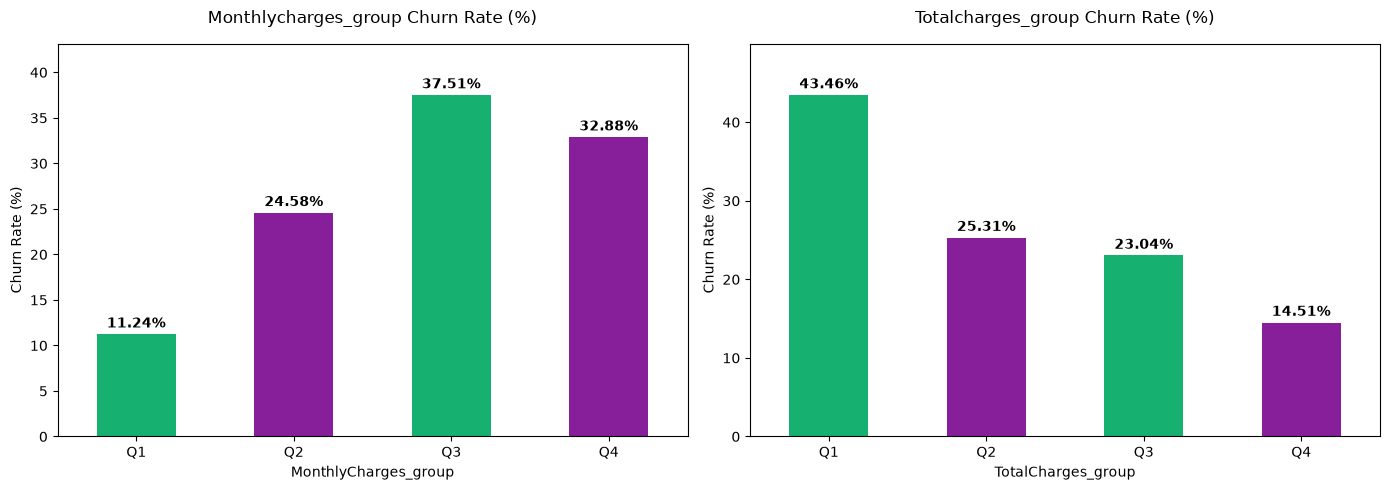

MonthlyCharges groups

  MonthlyCharges_group    Min     Max
0                   Q1  18.25   35.50
1                   Q2  35.55   70.35
2                   Q3  70.40   89.85
3                   Q4  89.90  118.75

TotalCharges groups

  TotalCharges_group      Min     Max
0                 Q1    18.80   401.3
1                 Q2   401.50  1397.3
2                 Q3  1397.65  3794.5
3                 Q4  3795.45  8684.8


In [29]:
plot_categorical_churn_rates(df, ['MonthlyCharges_group', 'TotalCharges_group'], 'Churn_bool')

# Create a reference tables with the actual value ranges for each quartile
monthly_ranges = df.groupby("MonthlyCharges_group", observed=False)["MonthlyCharges"].agg(
    Min="min",
    Max="max"
).reset_index()

total_ranges = df.groupby("TotalCharges_group", observed=False)["TotalCharges"].agg(
    Min="min",
    Max="max"
).reset_index()

print("="*25)
print("MonthlyCharges groups")
print("="*25)
print()
print(monthly_ranges)
print("")

print("="*25)
print("TotalCharges groups")
print("="*25)
print()
print(total_ranges)

En el análisis de la tasa de abandono por grupos de las variables financieras observamos:

En `MonthlyCharges` se observa un incremento considerable de la tasa de abandono conforme aumentan los cargos mensuales. Los clientes pertenecientes a *Q1* (18.25–35.50) presentan una tasa de abandono de 11.24%, mientras que en *Q2* (35.55–70.35) aumenta a 24.58%. La tasa alcanza su máximo en *Q3* (70.40–89.85), con 37.51%, y disminuye ligeramente en *Q4* (89.90–118.75), donde se registra un 32.88%.

Este comportamiento confirma el patrón observado anteriormente en la distribución por `Churn`: los clientes con cargos mensuales más elevados presentan, en general, mayores tasas de abandono. Sin embargo, el comportamiento no es completamente monotónico, ya que la tasa disminuye ligeramente entre *Q3* y *Q4*. Esto sugiere que la relación entre `MonthlyCharges` y `Churn` podría no ser estrictamente lineal.

En `TotalCharges` se observa el patrón contrario. Los clientes pertenecientes a *Q1* (18.80–401.30) presentan la tasa de abandono más elevada, con 43.46%. Esta tasa disminuye considerablemente en *Q2* (401.50–1,397.30), alcanzando 25.31%, y continúa disminuyendo en *Q3* (1,397.65–3,794.50), con 23.04%. Finalmente, *Q4* (3,795.45–8,684.80) presenta la menor tasa de abandono, con 14.51%.

El comportamiento de `TotalCharges` es consistente con lo observado anteriormente en la distribución por `Churn`, donde los clientes que abandonaron presentaban cargos totales considerablemente menores. Sin embargo, este resultado debe interpretarse con cautela, ya que `TotalCharges` está estrechamente relacionado con `tenure`: los clientes con menor antigüedad han tenido menos tiempo para acumular cargos.

En conjunto, `MonthlyCharges` y `TotalCharges` presentan patrones claramente diferenciados. Mientras que mayores cargos mensuales se asocian descriptivamente con mayores tasas de abandono, mayores cargos acumulados se relacionan con menores tasas de abandono. Estas diferencias serán evaluadas mediante las pruebas estadísticas correspondientes para determinar si existe evidencia estadística de diferencias entre los grupos de `Churn` y cuál es su magnitud.

### 8.3 Análisis estadístico de variables financieras

Ahora complementaremos el análisis descriptivo de `MonthlyCharges` y `TotalCharges` mediante pruebas estadísticas, con el objetivo de determinar si existen diferencias estadísticamente significativas en su distribución entre los clientes que permanecieron en el servicio y aquellos que lo abandonaron.

Debido a que ambas variables son numéricas continuas y presentan distribuciones que no requieren ser modeladas bajo el supuesto de normalidad, se utilizará la prueba U de Mann-Whitney para comparar ambos grupos.

Las hipótesis planteadas para cada variable son:

$$
H_0: \text{La distribución de la variable es igual entre ambos grupos de Churn.}
$$

$$
H_1: \text{La distribución de la variable es diferente entre ambos grupos de Churn.}
$$

Además del p-value obtenido mediante la prueba, se calculará el tamaño del efecto mediante la correlación $r$ de Rosenthal, utilizando la correlación rank-biserial como medida de efecto. Esto permitirá cuantificar la magnitud de las diferencias observadas y complementar la significancia estadística.

La interpretación del tamaño del efecto seguirá la escala utilizada anteriormente para `tenure`:

| $\|r\|$ | Interpretación |
|---:|---|
| < 0.10 | Muy pequeño |
| 0.10 – < 0.30 | Pequeño |
| 0.30 – < 0.50 | Moderado |
| ≥ 0.50 | Grande |

De esta manera, el análisis permitirá distinguir entre diferencias estadísticamente significativas y diferencias que además presentan una magnitud relevante, proporcionando evidencia adicional para evaluar el potencial de `MonthlyCharges` y `TotalCharges` como variables candidatas para el modelado.

In [30]:
# Perform Mann-Whitney U test for financial features
statistical_results = mann_whitney_analysis(
    df=df,
    features=financial_features,
    target="Churn_bool"
)

# Print results
statistical_results

,Variable,U Statistic,p-value,Rank-biserial r,Effect Size
0,MonthlyCharges,3667080.5,3.311628e-54,-0.241571,Pequeño
1,TotalCharges,6288982.0,1.995985e-84,0.303464,Moderado


Los resultados de la prueba U de Mann-Whitney muestran que tanto `MonthlyCharges` como `TotalCharges` presentan diferencias estadísticamente significativas entre los clientes que permanecieron en el servicio y aquellos que lo abandonaron. En ambos casos, el p-value es considerablemente inferior al nivel de significancia de 0.05, por lo que existe evidencia suficiente para rechazar la hipótesis nula de igualdad en la distribución de estas variables entre los grupos de `Churn`.

En `MonthlyCharges`, la prueba produce un p-value de aproximadamente 3.31 × 10⁻⁵⁴, indicando una diferencia estadísticamente significativa entre ambos grupos. El tamaño del efecto, medido mediante la correlación rank-biserial, es de -0.242, clasificado como pequeño. El signo negativo indica que los valores de `MonthlyCharges` tienden a ser mayores en el grupo de clientes que abandonaron el servicio, lo cual es consistente con el análisis descriptivo realizado anteriormente, donde el grupo *Yes* presentó una mediana de 79.65 frente a 64.43 en el grupo *No*. Sin embargo, la magnitud del efecto indica que la diferencia, aunque estadísticamente significativa, no es especialmente grande.

En `TotalCharges`, el p-value es aproximadamente 2.00 × 10⁻⁸⁴, proporcionando evidencia estadística muy fuerte de una diferencia entre los grupos. El tamaño del efecto es de 0.303, clasificado como moderado. El signo positivo indica que los valores de `TotalCharges` tienden a ser mayores en el grupo de clientes que permanecieron en el servicio. Esto coincide con el análisis descriptivo, donde la mediana fue de 1,683.60 para *No* y de 703.55 para *Yes*. Por lo tanto, la diferencia observada presenta no solo significancia estadística, sino también una magnitud moderada.

En conjunto, ambas variables presentan evidencia estadística de diferencias entre los grupos de `Churn`, aunque con magnitudes distintas. `TotalCharges` presenta el mayor tamaño del efecto, mientras que `MonthlyCharges` presenta un efecto pequeño. Estos resultados respaldan su consideración como variables candidatas para el modelado, aunque `TotalCharges` debe interpretarse con cautela debido a su estrecha relación con `tenure`.

Finalmente, estos resultados vuelven a mostrar la importancia de distinguir entre significancia estadística y magnitud del efecto. Debido al tamaño de la muestra, incluso diferencias relativamente pequeñas pueden producir p-values extremadamente bajos. Por ello, el tamaño del efecto proporciona información adicional para determinar qué diferencias tienen una magnitud potencialmente relevante.

## 10. Análisis de correlación entre variables numéricas.

Como parte del análisis exploratorio, se evaluará la relación entre las principales variables numéricas del conjunto de datos: `tenure`, `MonthlyCharges` y `TotalCharges`.

Para cuantificar estas relaciones se utilizará la correlación de Spearman, debido a que las variables no presentan una distribución normal y este método no requiere asumir normalidad ni una relación estrictamente lineal, sino una relación monotónica. Por este motivo, resulta más apropiado que la correlación de Pearson para este análisis.

En primer lugar, se utilizará una matriz de correlación para obtener una visión general de la intensidad y dirección de las relaciones entre las tres variables. Posteriormente, se profundizará en la relación entre `tenure` y `TotalCharges`, debido a su elevada relación conceptual: los cargos totales acumulados dependen, en gran medida, del tiempo que el cliente ha permanecido en el servicio.

La pregunta que se busca responder es:

> ¿Qué relaciones existen entre las variables numéricas y podrían indicar información redundante para el modelo predictivo?

Este análisis permitirá identificar relaciones potencialmente relevantes y posibles redundancias entre variables antes de la etapa de modelado predictivo.

In [31]:
# Define numerical features for correlation analysis
numerical_features = ["tenure", "MonthlyCharges", "TotalCharges"]

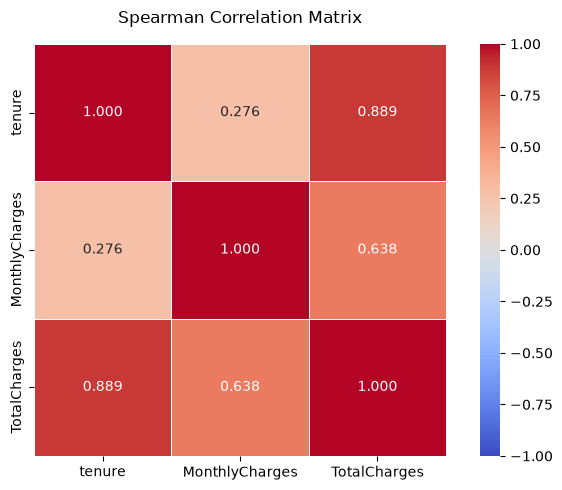

In [32]:
# Calculate the Spearman correlation matrix
correlation_matrix = df[numerical_features].corr(method="spearman")

# Create the correlation heatmap
plt.figure(figsize=(7, 5))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5
)

# Format plot
plt.title("Spearman Correlation Matrix", fontsize=12, pad=15)
plt.tight_layout()
plt.show()

La matriz de correlación de Spearman muestra que las tres variables numéricas presentan relaciones positivas, aunque con diferentes niveles de intensidad.

- La relación entre tenure y MonthlyCharges es positiva y débil ($\rho = 0.248$), lo que indica que los clientes con mayor antigüedad tienden a presentar cargos mensuales ligeramente superiores, aunque la relación no es particularmente fuerte.

- Entre MonthlyCharges y TotalCharges se observa una relación positiva moderada ($\rho = 0.651$). Esto indica que los clientes con mayores cargos mensuales tienden también a acumular mayores cargos totales.

- La relación más fuerte se encuentra entre tenure y TotalCharges, con un coeficiente de $\rho = 0.826$. 

A continuación analizaremos esta última relación mediante un scatter plot para la interpretación de ambas variables.

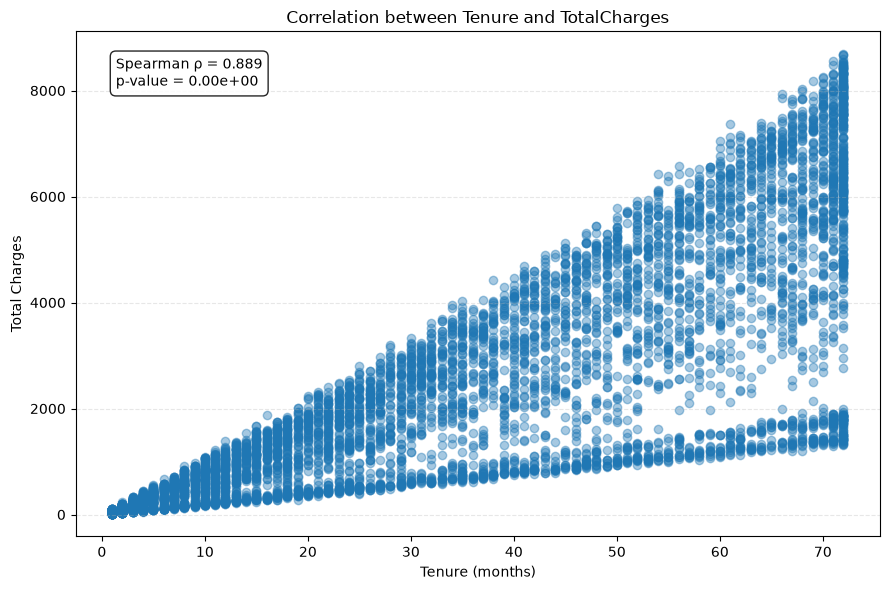

In [33]:
from scipy.stats import spearmanr

# Remove missing values from the variables being analyzed
correlation_data = df[["tenure", "TotalCharges"]].dropna()

# Calculate Spearman correlation
correlation, p_value = spearmanr(
    correlation_data["tenure"],
    correlation_data["TotalCharges"]
)

# Create scatter plot
plt.figure(figsize=(9, 6))

plt.scatter(
    correlation_data["tenure"],
    correlation_data["TotalCharges"],
    alpha=0.4
)

# Add correlation and p-value to the plot
plt.text(
    0.05,
    0.95,
    f"Spearman ρ = {correlation:.3f}\n"
    f"p-value = {p_value:.2e}",
    transform=plt.gca().transAxes,
    verticalalignment="top",
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.85)
)

# Format plot
plt.title("Correlation between Tenure and TotalCharges")
plt.xlabel("Tenure (months)")
plt.ylabel("Total Charges")

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

Como observamos en la matriz de correlación de Spearman, coeficiente de $\rho$ entre `tenure` y `TotalCharges` es de $\rho = 0.889$, lo que indica una relación monotónica positiva fuerte entre ambas variables. Esto significa que, en general, a medida que aumenta la antigüedad del cliente, también aumentan sus cargos totales acumulados.

El p-value obtenido es aproximadamente $0.00 \times 10^0$. Este valor debe interpretarse como un p-value extremadamente pequeño que se encuentra por debajo de la precisión de representación utilizada, y no como un valor literalmente igual a cero. Por lo tanto, existe evidencia estadística muy fuerte para rechazar la hipótesis nula de ausencia de correlación entre `tenure` y `TotalCharges`.

El patrón observado en el scatter plot es consistente con este resultado. Los clientes con poca antigüedad presentan valores bajos de `TotalCharges`, mientras que conforme aumenta `tenure`, los cargos acumulados tienden a incrementarse. La forma de embudo observada refleja que existe una relación positiva clara, pero también una mayor dispersión de `TotalCharges` entre los clientes con mayor antigüedad.

Esta fuerte correlación era esperable desde el punto de vista conceptual, ya que `TotalCharges` representa los cargos acumulados durante el tiempo que el cliente ha permanecido en el servicio. Por tanto, ambas variables contienen información relacionada y potencialmente redundante.

Este resultado deberá considerarse durante la etapa de modelado. Sin embargo, una correlación elevada no implica necesariamente que una de las variables deba eliminarse automáticamente. La decisión dependerá del modelo utilizado, su desempeño y, especialmente, del objetivo de interpretación de las variables.

## 11. Análisis de tasa de abandono en `Contract` y `tenure`

En los análisis individuales se observó que tanto `Contract` como `tenure` presentan una relación relevante con el abandono del servicio. Los clientes con contratos de menor duración y aquellos con menor antigüedad presentan tasas de churn considerablemente superiores.

A partir de estos resultados, se analizará la interacción entre ambas variables para determinar si el comportamiento del churn asociado al tipo de contrato varía según la antigüedad del cliente.

La pregunta que se busca responder es:

> ¿Cómo cambia la tasa de abandono según el tipo de contrato y la antigüedad del cliente?

Para ello, se calculará la tasa de churn para cada combinación de `Contract` y los grupos de `tenure`, con el objetivo de identificar posibles segmentos de clientes con un riesgo de abandono particularmente elevado.

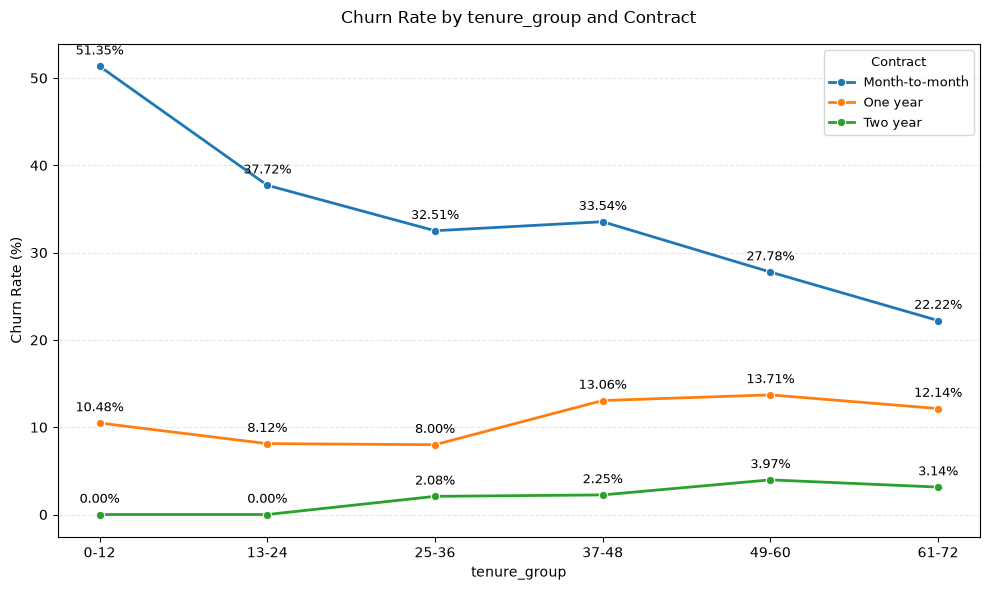

In [34]:
# Plot churn rate by tenure group and contract type
plot_churn_rate_by_group(
    df=df,
    x_feature="tenure_group",
    hue_feature="Contract",
    target="Churn_bool",
)

El análisis conjunto de `Contract` y `tenure` muestra diferencias importantes en la tasa de abandono entre las distintas combinaciones de antigüedad y tipo de contrato.

- Los clientes con contrato *Month-to-month* presentan las tasas de churn más elevadas en todos los grupos de `tenure`. El grupo con menor antigüedad (*0-12 meses*) alcanza una tasa de abandono de 51.35%, lo que indica que aproximadamente la mitad de estos clientes abandona el servicio. La tasa disminuye conforme aumenta la antigüedad, aunque incluso entre los clientes con 61-72 meses se mantiene relativamente elevada, con un churn de 22.22%. Esto refuerza la idea de que el contrato *Month-to-month* constituye un perfil de mayor riesgo, especialmente durante las primeras etapas de la relación con el cliente.

- En los clientes con contrato *One year*, las tasas de abandono son considerablemente menores. El churn comienza en 10.48% para clientes con 0-12 meses de antigüedad y se mantiene entre aproximadamente 8% y 14% en los grupos posteriores. A diferencia de *Month-to-month*, no se observa una disminución progresiva y clara del churn conforme aumenta `tenure`, lo que sugiere que el efecto de la antigüedad es mucho menos pronunciado dentro de este tipo de contrato.

- Los clientes con contrato *Two year* presentan las tasas de abandono más bajas en prácticamente todos los grupos de `tenure`. En el conjunto de datos no se observa ningún caso de churn durante los primeros 24 meses, mientras que en los grupos posteriores las tasas permanecen alrededor del 2-4%. Esto evidencia una elevada retención entre los clientes con contratos de mayor duración, independientemente de su antigüedad.

En conjunto, los resultados muestran que `Contract` parece ejercer una influencia importante sobre el riesgo de abandono y que su comportamiento varía según `tenure`. La diferencia entre los tipos de contrato es especialmente pronunciada entre los clientes con menor antigüedad: durante los primeros 12 meses, el churn alcanza 51.35% para *Month-to-month*, frente a 10.48% para *One year* y 0% para *Two year*.

Por otro lado, el efecto de `tenure` tampoco es uniforme entre los tipos de contrato. En *Month-to-month* se observa una reducción considerable del churn conforme aumenta la antigüedad, mientras que en *One year* y *Two year* las tasas permanecen relativamente estables y bajas. Esto sugiere una posible interacción entre ambas variables: el impacto de la antigüedad sobre el abandono parece ser considerablemente mayor entre los clientes con contrato *Month-to-month*.

Este análisis permite identificar un segmento particularmente vulnerable: clientes con baja antigüedad y contrato *Month-to-month*. Este perfil podría representar un grupo prioritario para estrategias de retención durante las primeras etapas de la relación con el cliente.

## 12. Análisis de tasa de abandono en `Contract` y `InternetService`

En los análisis anteriores se observó que `InternetService` presenta una relación relevante con el abandono del servicio. En particular, los clientes con servicio *Fiber optic* presentan tasas de churn considerablemente superiores a otras categorías.

A partir de estos resultados, se analizará la interacción entre las variables `InternetService` y `Contract` para determinar si el comportamiento del churn asociado al tipo de servicio de internet varía según el tipo de contrato del cliente.

La pregunta que se busca responder es:

> ¿Cómo cambia la tasa de abandono según el servicio de internet y el tipo de contrato del cliente?

Para ello, se calculará la tasa de churn para cada combinación de `InternetService` y `Contract`, con el objetivo de identificar posibles segmentos de clientes con un riesgo de abandono particularmente elevado y determinar si existe un patrón conjunto entre ambas variables.

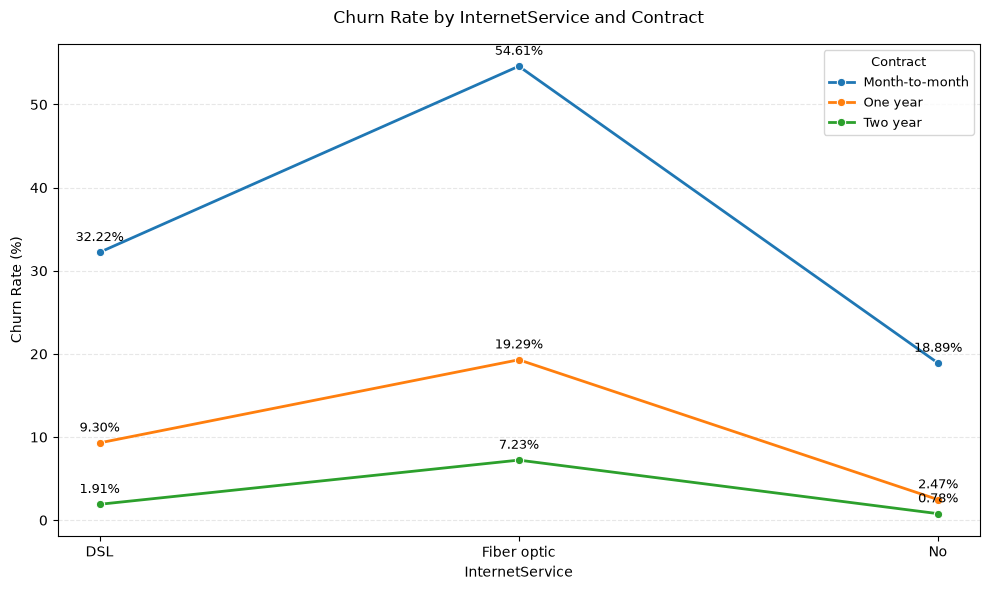

In [35]:
# Plot churn rate by internet service and contract type
plot_churn_rate_by_group(
    df=df,
    x_feature="InternetService",
    hue_feature="Contract",
    target="Churn_bool",
)

El análisis conjunto de `InternetService` y `Contract` muestra que la tasa de abandono varía considerablemente según la combinación de ambas variables. En general, se observa que el tipo de contrato mantiene una fuerte relación con el churn dentro de cada categoría de servicio de internet.

- Los clientes con contrato *Month-to-month* presentan las tasas de abandono más elevadas independientemente de su `InternetService`. Sin embargo, existen diferencias importantes entre los servicios: los clientes con *Fiber optic* alcanzan un churn de 54.61%, seguidos por *DSL* con 32.22% y aquellos sin servicio de internet con 18.89%. Esto indica que la combinación de contrato *Month-to-month* y servicio *Fiber optic* representa el perfil de mayor riesgo observado en este análisis.

- En los clientes con contrato *One year*, las tasas de abandono disminuyen considerablemente. El churn es de 19.29% para *Fiber optic*, 9.30% para *DSL* y apenas 2.47% para aquellos sin servicio de internet. Aunque las diferencias entre los tipos de servicio persisten, son considerablemente menores que las observadas entre los clientes con contrato *Month-to-month*.

- Los clientes con contrato *Two year* presentan las tasas de abandono más bajas en todas las categorías de `InternetService`. El churn es de 7.23% para *Fiber optic*, 1.91% para *DSL* y 0.78% para aquellos sin servicio de internet. Esto refuerza el patrón observado anteriormente: los contratos de mayor duración están asociados con una menor tasa de abandono incluso entre los clientes que presentan características de mayor riesgo, como tener servicio *Fiber optic*.

En conjunto, los resultados sugieren que `Contract` y `InternetService` presentan un comportamiento conjunto relevante. El efecto asociado con `InternetService` no es uniforme entre los tipos de contrato: las diferencias entre *Fiber optic*, *DSL* y la ausencia de servicio son mucho más pronunciadas entre los clientes con contrato *Month-to-month* que entre aquellos con contratos de mayor duración.

El segmento que presenta el mayor riesgo de abandono es, por tanto, el formado por clientes con *Fiber optic* y contrato *Month-to-month*, con una tasa de churn de 54.61%. Por el contrario, los clientes sin servicio de internet y con contrato *Two year* presentan una tasa de abandono de apenas 0.78%.

Este análisis permite identificar una posible interacción entre `InternetService` y `Contract`, ya que el comportamiento asociado con el servicio de internet parece depender del tipo de contrato. Esta relación podrá ser considerada posteriormente durante el modelado para determinar si aporta información predictiva adicional.

## 13. Análisis de tasa de abondono en `InternetService` y `Tenure`

En el análisis individual de `InternetService` se observó que los clientes con servicio *Fiber optic* presentan una tasa de abandono considerablemente superior a las demás categorías. Asimismo, en el análisis conjunto con `Contract`, se observó que esta diferencia se mantiene y se vuelve especialmente pronunciada entre los clientes con contrato Month-to-month.

Por otro lado, el análisis individual de `tenure` mostró que los clientes con menor antigüedad presentan un mayor riesgo de abandono. A partir de estos resultados, se analizará el comportamiento conjunto de ambas variables para determinar si la tasa de abandono asociada a `InternetService` varía según la antigüedad del cliente.

La pregunta que se busca responder es:

> ¿Cómo cambia la tasa de abandono según el tipo de servicio de internet y la antigüedad del cliente?

Para ello, se calculará la tasa de abandono para cada combinación de `tenure_group` e `InternetService`. Esto permitirá determinar si el elevado churn observado en los clientes con *Fiber optic* se concentra en determinados grupos de antigüedad o si se mantiene independientemente del tiempo que el cliente lleva en el servicio.

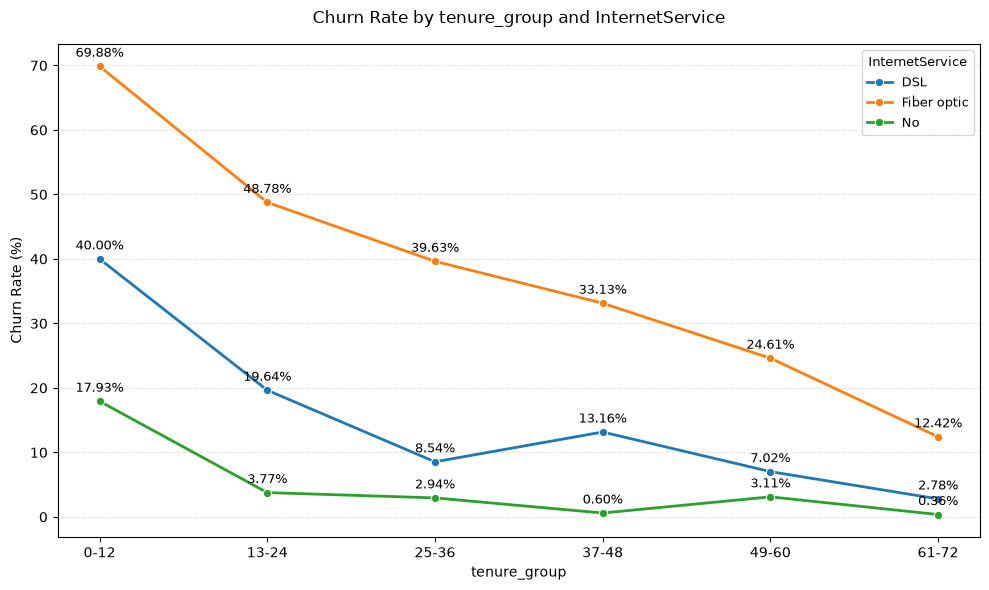

In [45]:
# Plot churn rate by internet service and tenure groups
plot_churn_rate_by_group(
    df=df,
    x_feature="tenure_group",
    hue_feature="InternetService",
    target="Churn_bool",
)

El análisis conjunto de `tenure` e `InternetService` muestra un patrón consistente: los clientes con servicio *Fiber optic* presentan la tasa de abandono más elevada en todos los grupos de antigüedad.

En el grupo de menor antigüedad (*0-12 meses*), los clientes con *Fiber optic* alcanzan un churn de 69.88%, considerablemente superior al observado en *DSL* (40.00%) y en los clientes sin servicio de internet (17.93%). Esto indica que la combinación de baja antigüedad y servicio *Fiber optic* concentra un nivel particularmente elevado de abandono.

A medida que aumenta `tenure`, la tasa de abandono disminuye en las tres categorías de `InternetService`. Sin embargo, la diferencia entre *Fiber optic* y las demás categorías se mantiene durante todos los grupos. En *Fiber optic*, el churn disminuye de 69.88% en *0-12 meses* a 12.42% en *61-72 meses*. Aunque existe una reducción considerable, continúa siendo superior al churn observado en *DSL* (2.78%) y en los clientes sin servicio de internet (0.36%) dentro del mismo grupo de antigüedad.

Este comportamiento indica que el elevado churn asociado con *Fiber optic* no se limita exclusivamente a los clientes nuevos. Si bien la antigüedad tiene un efecto importante sobre la tasa de abandono, el servicio de internet mantiene una diferencia considerable dentro de cada grupo de `tenure`.

El patrón también permite complementar el análisis realizado anteriormente con `Contract`. En aquel análisis, el elevado churn de *Fiber optic* era especialmente pronunciado entre los clientes con contrato *Month-to-month*. Al controlar ahora por grupos de `tenure`, se observa que la elevada tasa de abandono de *Fiber optic* persiste independientemente de la antigüedad del cliente.

Por lo tanto, los resultados sugieren que `InternetService` podría estar capturando información adicional sobre el riesgo de abandono que no puede explicarse únicamente por `tenure`. Sin embargo, estos resultados muestran asociación y no permiten establecer que el servicio *Fiber optic* sea la causa del abandono.

Finalmente, el elevado churn observado en *Fiber optic*, particularmente entre los clientes con menor antigüedad, plantea una hipótesis que podría explorarse posteriormente: determinar si esta categoría está relacionada con otras características del cliente, como `MonthlyCharges`, `Contract` o determinados servicios adicionales, que puedan ayudar a explicar su mayor tasa de abandono.

## 14. Análisis de tasa de abandono en `tenure` and `MonthlyCharges`

En los análisis individuales se observó que `tenure` presenta una relación importante con el abandono, donde los clientes con menor antigüedad muestran tasas de churn más elevadas. Por otro lado, `MonthlyCharges` también presenta diferencias en la tasa de abandono entre sus distintos grupos, con un churn mayor entre los clientes que presentan cargos mensuales más elevados.

A partir de estos resultados, se analizará el comportamiento conjunto de ambas variables para determinar si el nivel de cargos mensuales está asociado con diferentes tasas de abandono dependiendo de la antigüedad del cliente.

La pregunta que se busca responder es:

> ¿Cómo cambia la tasa de abandono según la antigüedad del cliente y el nivel de cargos mensuales?

Para ello, se calculará la tasa de churn para cada combinación de `tenure_group` y `MonthlyCharges_group`. Esto permitirá identificar posibles segmentos de clientes que combinen una baja antigüedad con cargos mensuales elevados y determinar si presentan un riesgo de abandono particularmente alto.

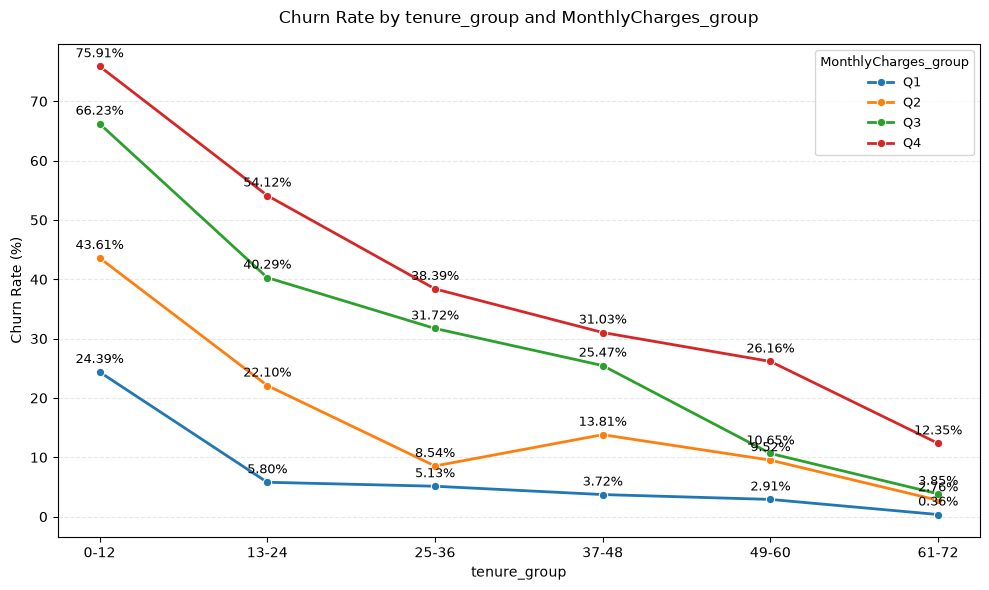

MonthlyCharges groups

  MonthlyCharges_group    Min     Max
0                   Q1  18.25   35.50
1                   Q2  35.55   70.35
2                   Q3  70.40   89.85
3                   Q4  89.90  118.75



In [56]:
# Plot churn rate by monthly charges groups and tenure groups
plot_churn_rate_by_group(
    df=df,
    x_feature="tenure_group",
    hue_feature="MonthlyCharges_group",
    target="Churn_bool",
)

print("="*25)
print("MonthlyCharges groups")
print("="*25)
print()
print(monthly_ranges)
print("")

El análisis conjunto de `tenure` y `MonthlyCharges` muestra un patrón consistente en el que la tasa de abandono disminuye conforme aumenta la antigüedad del cliente, mientras que aumenta conforme se incrementan los cargos mensuales.

La combinación con mayor tasa de abandono corresponde a los clientes con menor antigüedad (*0-12 meses*) y cargos mensuales más elevados (*Q4*), con un churn de 75.91%. En contraste, los clientes con mayor antigüedad (*61-72 meses*) y cargos mensuales más bajos (*Q1*) presentan una tasa de abandono de apenas 0.36%.

Dentro de cada grupo de `tenure`, se observa una tendencia clara: el churn aumenta progresivamente desde *Q1* hasta *Q4* de `MonthlyCharges`. Por ejemplo, entre los clientes con *0-12 meses* de antigüedad, la tasa de abandono aumenta de 24.39% en *Q1* hasta 75.91% en *Q4*. Este mismo patrón se mantiene en los demás grupos de antigüedad.

De manera similar, dentro de cada grupo de `MonthlyCharges`, la tasa de abandono disminuye conforme aumenta `tenure`. En el grupo de cargos más elevados (*Q4*), el churn disminuye de 75.91% entre los clientes con *0-12 meses* a 12.35% entre aquellos con *61-72 meses* de antigüedad.

Este comportamiento sugiere que ambas variables aportan información relevante sobre el riesgo de abandono y que sus efectos se presentan de manera consistente cuando se analizan conjuntamente. La combinación de baja antigüedad y cargos mensuales elevados identifica particularmente a los clientes con mayor riesgo de churn.

Sin embargo, estos resultados deben interpretarse como asociaciones y no como evidencia de causalidad. Un mayor `MonthlyCharges` no implica necesariamente que los cargos elevados provoquen el abandono, ya que estos pueden estar relacionados con otras características del servicio contratado. Por ello, será necesario considerar estas variables conjuntamente con otros factores durante el modelado predictivo.

En términos de segmentación, el análisis identifica un perfil de alto riesgo particularmente claro: clientes nuevos con cargos mensuales elevados. Este segmento podría ser relevante para estrategias de retención temprana y será importante comprobar posteriormente si esta relación también se refleja en el modelo predictivo.

In [57]:
round(df.groupby(['tenure_group', 'MonthlyCharges_group'])['Churn_bool'].mean()*100,2)

tenure_group  MonthlyCharges_group
0-12          Q1                      24.39
              Q2                      43.61
              Q3                      66.23
              Q4                      75.91
13-24         Q1                       5.80
              Q2                      22.10
              Q3                      40.29
              Q4                      54.12
25-36         Q1                       5.13
              Q2                       8.54
              Q3                      31.72
              Q4                      38.39
37-48         Q1                       3.72
              Q2                      13.81
              Q3                      25.47
              Q4                      31.03
49-60         Q1                       2.91
              Q2                       9.52
              Q3                      10.65
              Q4                      26.16
61-72         Q1                       0.36
              Q2                       2.

In [111]:
for var in financial_features:
    table_dist = df.groupby('Churn')[var].describe([0.1, 0.25, 0.50, 0.75, 0.90]).T
    print(f'VARIABLE: {var}')
    print(table_dist)
    print("")

VARIABLE: MonthlyCharges
Churn           No          Yes
count  5174.000000  1869.000000
mean     61.265124    74.441332
std      31.092648    24.666053
min      18.250000    18.850000
10%      19.950000    34.700000
25%      25.100000    56.150000
50%      64.425000    79.650000
75%      88.400000    94.200000
90%     103.135000   101.770000
max     118.750000   118.350000

VARIABLE: TotalCharges
Churn           No          Yes
count  5163.000000  1869.000000
mean   2555.344141  1531.796094
std    2329.456984  1890.822994
min      18.800000    18.850000
10%     158.470000    59.640000
25%     577.825000   134.500000
50%    1683.600000   703.550000
75%    4264.125000  2331.300000
90%    6293.100000  4556.790000
max    8672.450000  8684.800000



In [122]:
for var in ['MonthlyCharges_group', 'TotalCharges_group']:
    churn_rate = df.groupby(var)['Churn_bool'].mean() * 100
    print(f'VARIABLE: {var}')
    print(churn_rate.round(2))
    print("")

VARIABLE: MonthlyCharges_group
MonthlyCharges_group
Q1    11.24
Q2    24.58
Q3    37.51
Q4    32.88
Name: Churn_bool, dtype: float64

VARIABLE: TotalCharges_group
TotalCharges_group
Q1    43.46
Q2    25.31
Q3    23.04
Q4    14.51
Name: Churn_bool, dtype: float64



In [67]:
for var in service_features:
    table_churn = df.groupby(var)['Churn_bool'].mean()*100
    print(table_churn.round(2))
    print("")

PhoneService
No     24.93
Yes    26.71
Name: Churn_bool, dtype: float64

MultipleLines
No                  25.04
No phone service    24.93
Yes                 28.61
Name: Churn_bool, dtype: float64

InternetService
DSL            18.96
Fiber optic    41.89
No              7.40
Name: Churn_bool, dtype: float64

OnlineSecurity
No                     41.77
No internet service     7.40
Yes                    14.61
Name: Churn_bool, dtype: float64

OnlineBackup
No                     39.93
No internet service     7.40
Yes                    21.53
Name: Churn_bool, dtype: float64

DeviceProtection
No                     39.13
No internet service     7.40
Yes                    22.50
Name: Churn_bool, dtype: float64

TechSupport
No                     41.64
No internet service     7.40
Yes                    15.17
Name: Churn_bool, dtype: float64

StreamingTV
No                     33.52
No internet service     7.40
Yes                    30.07
Name: Churn_bool, dtype: float64

StreamingMovie

In [68]:
for var in ['tenure_group']:
    abs = df[var].value_counts()
    rel = df[var].value_counts(normalize=True)

    table = pd.concat([abs, rel], axis=1)
    print(f'VARIABLE: {var}')
    print(table)
    print("")

VARIABLE: tenure_group
              count  proportion
tenure_group                   
0-12           2186    0.310379
61-72          1407    0.199773
13-24          1024    0.145393
25-36           832    0.118131
49-60           832    0.118131
37-48           762    0.108193

